# Sessão 2 — Preços nodais e econometria espacial: do OPF aos *spillovers*

**Minicurso LaPSEE · UNESP Ilha Solteira**

> **Versão didática passo a passo.** Assim como na Sessão 1, todo o código que antes vivia
> escondido em `lapsee_s02.py` se constrói aqui **diante de vocês**, com a física, a
> economia e a estatística explicadas antes de cada bloco.

## 🎯 O fio condutor de hoje

Na Sessão 1 aprendemos a ler a rede como um **grafo**. Hoje vamos lê-la como um **mercado**:

1. **De onde saem os preços?** O preço nodal (*LMP*) é a variável dual do despacho
   ótimo (DC-OPF). Veremos isso primeiro em um mercado de brinquedo de 2 barras que se resolve
   *à mão*, e depois no IEEE 30.
2. **Os preços se agrupam no espaço?** Construiremos um painel de 200 horas de LMPs e o
   interrogaremos com o estatístico de **Moran**.
3. **Como se modela essa dependencia?** Bateria de diagnósticos LM → modelos **SAR/SEM** →
   efeitos **diretos / indiretos / totais** de LeSage & Pace: a ferramenta que converte
   uma regressão em uma recomendação de política.
4. **Onde conviene instalar generação?** Lab 2b no IEEE 118: um índice de aptidão para
   *DG siting* e a diferença entre rankear por efeito próprio (míope) ou por efeito total.
5. **Isto pasa em redes reais?** Checagem de realidade com **RTS-GMLC** (NREL): preços
   negativos incluídos.

| Bloque | Caso de estudo | Tiempo objetivo |
|---|---|---|
| §1 De onde saem os preços | 2 barras (brinquedo) + IEEE 30 | 15 min |
| §2 Painel e Moran's $I$ | IEEE 30 (200 h) | 15 min |
| §3 OLS → SAR/SEM → efeitos | IEEE 30 | 30 min |
| §4 *Siting* de generação | IEEE 118 | 25 min |
| §5 Checagem de realidade | RTS-GMLC (NREL) | 15 min |
| §6 Capstone: robustez em $W$ | os três | opcional |

## 🧭 Como ler este notebook

Mismo código de colores que a Sessão 1: markdown com o *porquê* → código curto e comentado
→ 💡 **Interpretação** → ✏️ **Para refletir**. As funções definidas aqui coincidem com as
de `lapsee_s02.py`, assim podem migrar à versão "de produção" quando dominen o passo a passo.

---
## 0 · Preparação do ambiente

Além das bibliotecas da Sessão 1, hoje entram as três do ecossistema **PySAL**:

| Biblioteca | Para que a usamos |
|---|---|
| `libpysal` | O objeto `W` de pesos espaciais que consomem os estimadores |
| `esda` | Moran's $I$ global e local (LISA) |
| `spreg` | OLS com diagnósticos espaciais, SAR (`ML_Lag`) e SEM (`ML_Error`) |

> Se falta alguma: `pip install libpysal esda spreg`

In [1]:
from __future__ import annotations

import json
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pandapower as pp
import pandapower.networks as pn

from libpysal.weights import W as PysalW
from esda.moran import Moran, Moran_Local
import spreg

# --- Reproducibilidad --------------------------------------------------------
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)
np.random.seed(RANDOM_SEED)              # spreg/esda usan o RNG global

# --- Silenciar o ruído interno de pandapower (avisos de limites de tensão) --
logging.getLogger("pandapower").setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore")

# --- Estética uniforme ---------------------------------------------------------
plt.rcParams.update({
    "figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})
AZUL, VERMELHO, CINZA = "#1F3A5F", "#C8102E", "#a0a0a0"

print("pandapower", pp.__version__, "| spreg", spreg.__version__)

pandapower 3.4.0 | spreg 1.9.0


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 0.1 Helpers que traemos da Sessão 1

Quatro funções que já construímos passo a passo a aula passada (coordenadas, ramos em p.u.,
Laplaciano $B$ e PTDF). As redefinimos compactas — se alguma não parecer familiar,
voltem ao notebook da Sessão 1, onde cada uma se constrói e se valida linha a linha.

In [2]:
def coords_das_barras(net):
    "{bus: (x, y)} — compatible com pandapower 2.x (bus_geodata) e 3.x (coluna geo)."
    if hasattr(net, "bus_geodata") and len(getattr(net, "bus_geodata", [])):
        return {int(b): (float(net.bus_geodata.at[b, "x"]),
                         float(net.bus_geodata.at[b, "e"])) for b in net.bus.index}
    return {int(b): tuple(json.loads(g)["coordinates"][:2])
            for b, g in net.bus["geo"].items()}


def ramos_da_rede(net):
    "(i, j, x_pu, tipo) por cada linha/trafo, com correção de tap (ver S1 §2.1)."
    S_base = net.sn_mva
    for _, ln in net.line.iterrows():
        vn = net.bus.loc[int(ln.from_bus), "vn_kv"]
        yield int(ln.from_bus), int(ln.to_bus), \
              float(ln.x_ohm_per_km * ln.length_km / (vn**2 / S_base)), "linha"
    for _, tr in net.trafo.iterrows():
        x_pu = (tr.vk_percent / 100.0) * (S_base / tr.sn_mva)
        if not np.isnan(tr.tap_pos):
            x_pu *= 1 + (tr.tap_pos - tr.tap_neutral) * tr.tap_step_percent / 100.0
        yield int(tr.hv_bus), int(tr.lv_bus), float(x_pu), "trafo"


def grafo_topologico(net):
    G = nx.Graph(); G.add_nodes_from(sorted(net.bus.index))
    for i, j, _x, _t in ramos_da_rede(net):
        G.add_edge(i, j)
    return G


def laplaciano_suscetancias(net, bidx):
    n = len(bidx); B = np.zeros((n, n))
    for i, j, x_pu, _t in ramos_da_rede(net):
        if abs(x_pu) < 1e-12: continue
        b = 1.0 / x_pu; ii, jj = bidx[i], bidx[j]
        B[ii, jj] -= b; B[jj, ii] -= b; B[ii, ii] += b; B[jj, jj] += b
    return B


def ptdf_da_rede(net):
    "Devuelve (PTDF L×n, lista de ramos em índice 0..n-1, bidx)."
    bidx = {b: i for i, b in enumerate(sorted(net.bus.index))}
    B = laplaciano_suscetancias(net, bidx)
    slack = bidx[int(net.ext_grid.bus.iloc[0])]
    resto = [k for k in range(len(bidx)) if k != slack]
    B_inv = np.linalg.inv(B[np.ix_(resto, resto)])
    ramos, bs = [], []
    for i, j, x_pu, _t in ramos_da_rede(net):
        if abs(x_pu) < 1e-12: continue
        ramos.append((bidx[i], bidx[j])); bs.append(1.0 / x_pu)
    PTDF = np.zeros((len(ramos), len(bidx)))
    pos_de = {k: c for c, k in enumerate(resto)}
    for l, (i, j) in enumerate(ramos):
        fila = np.zeros(len(resto))
        if i != slack: fila[pos_de[i]] += bs[l]
        if j != slack: fila[pos_de[j]] -= bs[l]
        PTDF[l, resto] = fila @ B_inv
    return PTDF, ramos, bidx

---
## 1 · De onde saem os preços? O dual do DC-OPF

### 1.1 A economia em uma caixa

O **despacho ótimo** (DC-OPF) resolve:

$$\min_{g}\;\sum_i c_i\, g_i
\quad\text{s.a.}\quad
\underbrace{P = B\theta}_{\text{balanço nodal }(\lambda_i)},\qquad
\underbrace{|p_\ell| \le \bar p_\ell}_{\text{limites de línea }(\mu_\ell)},\qquad
g_i^{min} \le g_i \le g_i^{max}.$$

O **preço nodal** $LMP_i$ é, *por definição*, a variável dual $\lambda_i$ do balanço em
a barra $i$: quanto custa servir um MW adicional de demanda **aí**. Schweppe et al. (1988)
demonstraram a decomposição (sem perdas):

$$\boxed{LMP_i \;=\; \lambda_{\text{energia}} \;-\; \sum_\ell \mu_\ell\,\mathrm{PTDF}_{\ell i}}$$

- $\lambda_{\text{energia}}$: o preço "da energia", comum a todo o sistema;
- o segundo termo: a sobretaxa (ou o desconto) por **congestionamento**, que pasa pela PTDF que
  construímos na Sessão 1. **Sem linhas saturadas, $\mu_\ell = 0$ e todos pagam o mesmo.**

### 1.2 O mercado mais pequeno do mundo: 2 barras

Antes do IEEE 30, um caso que se resolve **à mão no quadro**:

```
   barra A                         barra B
   gen barato ($10/MWh) ──────── gen caro ($30/MWh)
   capacidade 300 MW    linha      capacidade 300 MW
                      limite       carga = 100 MW
                      60 MW
```

**Predição (façam-na antes de rodar a célula):** o gen barato querría servir os 100 MW,
mas a linha só deixa pasar 60. Então: A exporta 60, o gen caro cubre os 40 restantes.
- $LMP_A$ = custo marginal do gen barato = **\$10** (um MW extra de demanda em A o atende ele);
- $LMP_B$ = custo marginal do gen caro = **\$30** (um MW extra em B não pode vir pela
  linha cheia: o atende o caro).

De passo aprendemos a **construir uma rede desde zero** com pandapower.

In [3]:
# ---- Construção explícita do mercado de brinquedo --------------------------
toy = pp.create_empty_network(sn_mva=100)

bA = pp.create_bus(toy, vn_kv=132, name="A (gen barato)")
bB = pp.create_bus(toy, vn_kv=132, name="B (gen caro + carga)")

# Linha A-B com limite térmico de 60 MVA  (max_i_ka = MVA / (√3·kV))
pp.create_line_from_parameters(toy, bA, bB, length_km=1.0,
                               r_ohm_per_km=0.05, x_ohm_per_km=17.4, c_nf_per_km=0.0,
                               max_i_ka=60 / (np.sqrt(3) * 132))
toy.line["max_loading_percent"] = 100.0

# Generador barato em A: o declaramos ext_grid (também faz de slack)
eg = pp.create_ext_grid(toy, bus=bA, min_p_mw=0, max_p_mw=300)
pp.create_poly_cost(toy, eg, "ext_grid", cp1_eur_per_mw=10.0)   # $10/MWh

# Generador caro em B
g = pp.create_gen(toy, bus=bB, p_mw=0, min_p_mw=0, max_p_mw=300, controllable=True)
pp.create_poly_cost(toy, g, "gen", cp1_eur_per_mw=30.0)          # $30/MWh

# A carga: 100 MW em B
pp.create_load(toy, bus=bB, p_mw=100.0, controllable=False)

# ---- Resolver o despacho ótimo e ler os duais ---------------------------
pp.rundcopp(toy)
print(f"Fluxo pela linha : {toy.res_line.p_from_mw.iloc[0]:6.1f} MW "
      f"(cargada ao {toy.res_line.loading_percent.iloc[0]:.0f}%)")
print(f"Despacho gen caro  : {toy.res_gen.p_mw.iloc[0]:6.1f} MW")
print(f"LMP barra A        : {toy.res_bus.lam_p.iloc[0]:6.2f} $/MWh")
print(f"LMP barra B        : {toy.res_bus.lam_p.iloc[1]:6.2f} $/MWh")

Fluxo pela linha :   60.0 MW (cargada ao 100%)
Despacho gen caro  :   40.0 MW
LMP barra A        :  10.00 $/MWh
LMP barra B        :  30.00 $/MWh


✔️ **Exatamente a previsão do quadro**: linha a 100%, o caro despacha 40 MW, e os
preços se separam em \$10 / \$30. A diferença de \$20/MWh é **o preço-sombra da
linha** ($\mu$): o que o sistema pagaria por 1 MW a mais de capacidade de transmissão.

### 1.3 O experimento de controle: e se a linha fosse grande?

Para nos convencermos de que a **congestionamento** (e não outra coisa) separa os preços, repetimos o
despacho com uma linha de 200 MW.

In [4]:
toy.line["max_i_ka"] = 200 / (np.sqrt(3) * 132)     # ampliamos a linha a 200 MVA
pp.rundcopp(toy)
print(f"Fluxo pela linha : {toy.res_line.p_from_mw.iloc[0]:6.1f} MW "
      f"({toy.res_line.loading_percent.iloc[0]:.0f}% de carga)")
print(f"Despacho gen caro  : {toy.res_gen.p_mw.iloc[0]:6.1f} MW")
print(f"LMP barra A        : {toy.res_bus.lam_p.iloc[0]:6.2f} $/MWh")
print(f"LMP barra B        : {toy.res_bus.lam_p.iloc[1]:6.2f} $/MWh")
print("\n=> Sem congestionamento, um só preço para todo o sistema: λ_energia = $10.")

Fluxo pela linha :  100.0 MW (50% de carga)
Despacho gen caro  :    0.0 MW
LMP barra A        :  10.00 $/MWh
LMP barra B        :  10.00 $/MWh

=> Sem congestionamento, um só preço para todo o sistema: λ_energia = $10.


💡 **A ideia que organiza toda a sessão:** a congestionamento converte *um* commodity (energia)
em *n* commodities (energia-em-la-barra-$i$). A estrutura espacial dos preços **é** a
impressão digital das restrições de rede — por isso tem sentido analisarla com as ferramentas
espaciais da Sessão 1.

✏️ **Para refletir:** no brinquedo congestionado, quanto pagaria a carga se o regulador
impusesse um preço único médio? Quem ganharia e quem perderia em relação ao LMP? (Isto
é, em miniatura, o debate *zonal vs. nodal* dos mercados europeus.)

---
## 2 · O IEEE 30 como mercado

### 2.1 Um detalhe dos dados que muda tudo: os limites de linha

O IEEE 30 de pandapower traz `max_i_ka = 99999` — linhas *infinitas*. Com isso **nunca** há
congestionamento e o exercício morre antes de começar. Atribuímos a elas limites realistas:

- troncal de **132 kV → 50 MVA** por linha;
- anel de **33 kV → 16 MVA**.

(Calibrados para que 1–3 linhas saturem sob carga base — suficiente congestionamento para que o
problema seja interessante, sem tornar o OPF infactível.) A conversão é a mesma do
brinquedo: $I_{max}[\text{kA}] = \dfrac{S[\text{MVA}]}{\sqrt{3}\cdot V[\text{kV}]}$.

Os **custos marginais** já vêm no caso: o slack e o gen 0 ofertam a \$20/MWh, os
outros quatro a \$40/MWh — dois "tecnologias", como carvão vs. gas.

In [5]:
def ieee30_para_opf(mva_hv=50.0, mva_lv=16.0):
    "IEEE 30 com limites térmicos realistas (a versão do helper, explicitada)."
    net = pn.case_ieee30()
    for i, ln in net.line.iterrows():
        vn = net.bus.loc[int(ln.from_bus), "vn_kv"]        # 132 kV o 33 kV?
        mva_lim = mva_hv if vn > 100 else mva_lv
        net.line.loc[i, "max_i_ka"] = mva_lim / (np.sqrt(3) * vn)
    net.line["max_loading_percent"] = 100.0
    net.trafo["max_loading_percent"] = 100.0
    return net


net = ieee30_para_opf()
pp.rundcopp(net)                                            # primeiro OPF de verdade!

print(f"Custo do despacho ótimo : {net.res_cost:,.0f} $/h")
print(f"Carga total               : {net.load.p_mw.sum():.1f} MW")
print("Ofertas dos geradores ($/MWh):")
display(net.poly_cost[["element", "et", "cp1_eur_per_mw"]])

Custo do despacho ótimo : 9,596 $/h
Carga total               : 283.4 MW
Ofertas dos geradores ($/MWh):


,element,et,cp1_eur_per_mw
0,0,ext_grid,20.0
1,0,gen,20.0
2,1,gen,40.0
3,2,gen,40.0
4,3,gen,40.0
5,4,gen,40.0


### 2.2 A foto dos preços: decomposição de Schweppe

Do OPF resolvido leemos os duais (`res_bus.lam_p`) e os partimos:

- $\lambda_{\text{energia}}$ = LMP da barra slack (sua coluna da PTDF é zero por
  construção, portanto seu preço não tem componente de congestionamento);
- congestionamento$_i$ = $LMP_i - \lambda_{\text{energia}}$ (a decomposição *empírica*: pandapower
  não persiste os $\mu_\ell$, mas não os precisamos para separar as duas componentes).

In [6]:
def foto_lmp(net):
    "Descomposição empírica de Schweppe a partir de um OPF resolvido."
    barras = sorted(net.bus.index)
    lmp = net.res_bus["lam_p"].reindex(barras).values
    lambda_E = float(net.res_bus.loc[int(net.ext_grid.bus.iloc[0]), "lam_p"])
    n_bind = int((net.res_line["loading_percent"] > 99.9).sum()) \
           + int((net.res_trafo["loading_percent"] > 99.9).sum())
    return {"lmp": lmp, "lambda_energia": lambda_E,
            "congestion": lmp - lambda_E, "n_binding": n_bind,
            "spread": float(lmp.max() - lmp.min())}


foto = foto_lmp(net)
barras = sorted(net.bus.index)
print(f"λ_energia            : {foto['lambda_energia']:.2f} $/MWh")
print(f"Spread (max − min)   : {foto['spread']:.2f} $/MWh")
print(f"Restrições ativas: {foto['n_binding']}")

λ_energia            : 26.83 $/MWh
Spread (max − min)   : 17.76 $/MWh
Restrições ativas: 2


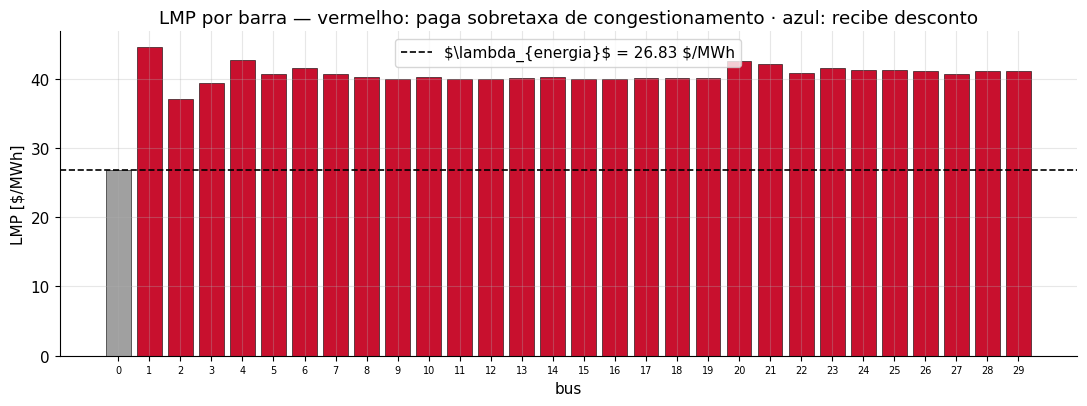

In [7]:
# ---- Barra por barra: quem paga a sobretaxa de congestionamento? ------------------
lam_E = foto["lambda_energia"]
colores = [VERMELHO if c > 1e-6 else AZUL if c < -1e-6 else CINZA
           for c in foto["congestion"]]

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(range(len(barras)), foto["lmp"], color=colores, edgecolor="k", lw=0.4)
ax.axhline(lam_E, color="k", ls="--", lw=1.2,
           label=f"$\\lambda_{{energia}}$ = {lam_E:.2f} $/MWh")
ax.set_xticks(range(len(barras))); ax.set_xticklabels(barras, fontsize=7)
ax.set_xlabel("bus"); ax.set_ylabel("LMP [$/MWh]")
ax.set_title("LMP por barra — vermelho: paga sobretaxa de congestionamento · azul: recibe desconto")
ax.legend(); plt.tight_layout(); plt.show()

💡 **Como ler.** As barras **vermelhas** (LMP > $\lambda_E$) são **bolsões de carga**: um MW
extra aí deve cruzar uma linha saturada, portanto custa mais. As **azuis** são **bolsões
de geração presa**: um MW injetado aí vale menos porque a linha cheia não pode
escoá-lo. Este padrão *alto-em-la-carga / baixo-em-o-gerador-preso* é exatamente a
sinal espacial que os modelos de §3 vão capturar.

### 2.3 O mapa de preços (a figura que faltaba)

O gráfico de barras perde a **geografia**. Pintemos a rede: color do nó = LMP, linhas
saturadas em vermelho grosso. Aqui se *ve* a fronteira de preços.

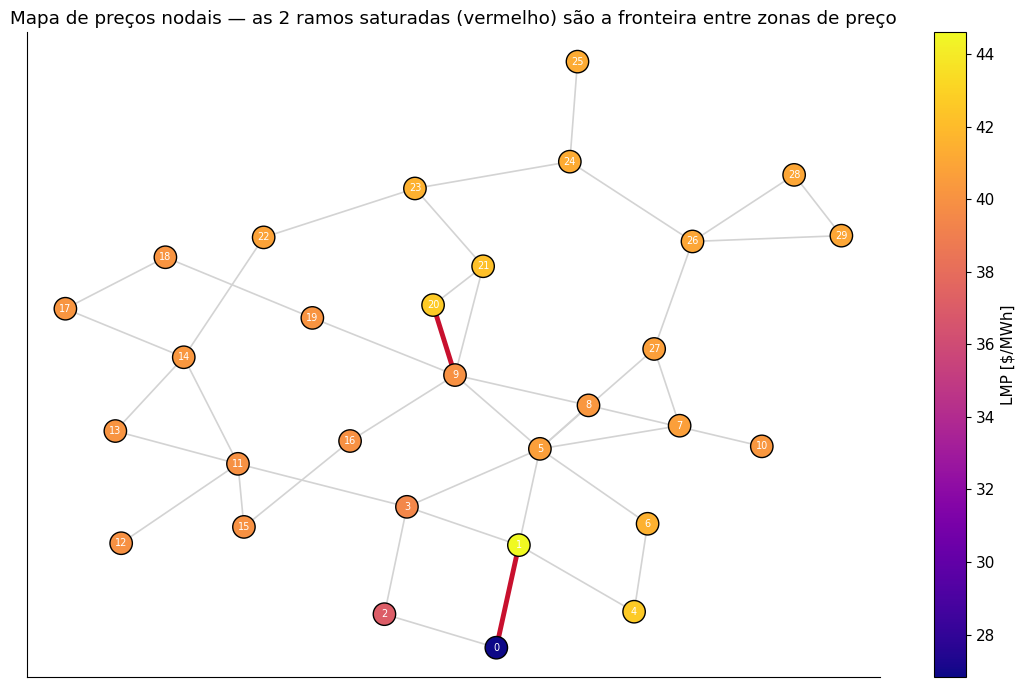

In [8]:
pos = coords_das_barras(net)
G30 = grafo_topologico(net)

# que ramos estão saturadas?
sat_linhas = [(int(r.from_bus), int(r.to_bus))
              for i, r in net.line.iterrows()
              if net.res_line.loading_percent[i] > 99.9]
sat_trafos = [(int(r.hv_bus), int(r.lv_bus))
              for i, r in net.trafo.iterrows()
              if net.res_trafo.loading_percent[i] > 99.9]
saturadas = set(map(frozenset, sat_linhas + sat_trafos))

fig, ax = plt.subplots(figsize=(11, 7))
for u, v in G30.edges():
    (x1, y1), (x2, y2) = pos[u], pos[v]
    if frozenset((u, v)) in saturadas:
        ax.plot([x1, x2], [y1, y2], color=VERMELHO, lw=3.5, zorder=2,
                solid_capstyle="round")
    else:
        ax.plot([x1, x2], [y1, y2], color="lightgray", lw=1.2, zorder=1)

sc = ax.scatter([pos[b][0] for b in barras], [pos[b][1] for b in barras],
                c=foto["lmp"], cmap="plasma", s=260, edgecolors="k", zorder=3)
for b in barras:
    ax.annotate(str(b), pos[b], ha="center", va="center", fontsize=7,
                color="white", zorder=4)
plt.colorbar(sc, label="LMP [$/MWh]")
ax.set_title(f"Mapa de preços nodais — as {len(saturadas)} ramos saturadas (vermelho) "
             "são a fronteira entre zonas de preço")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

💡 **Interpretação.** Compare-se com a bipartição espectral da Sessão 1 (§3.1): as
ramos saturadas funcionam como aquelas arestas "fronteira" — e os preços saltam justo ao
cruzá-las. *A estrutura do grafo prediz onde pode romperse o preço único.*

### 2.4 Por quê algumas barras movem mais os preços? A coluna PTDF

A decomposição de Schweppe diz que a sobretaxa da barra $i$ é
$-\sum_\ell \mu_\ell \mathrm{PTDF}_{\ell i}$: só importam as linhas **saturadas**. Olhemos
a linha da PTDF da ramo mais cargada — nos diz que barras a "empurram" e quais a
"aliviam".

Linhas saturadas: [0, 20]
  linha 0 (0->1): 0 barras a cargan, 29 a aliviam
  linha 20 (9->20): 11 barras a cargan, 18 a aliviam


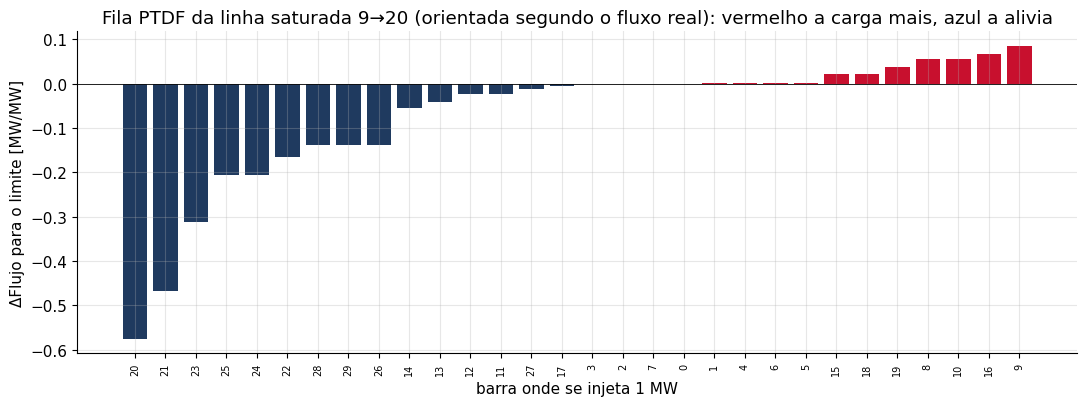

In [9]:
PTDF, ramos_idx, bidx = ptdf_da_rede(net)
rev = {v: k for k, v in bidx.items()}

# As linhas saturadas (no mesmo orden que net.line dentro da PTDF)
linhas_bind = [int(i) for i in net.res_line.index
               if net.res_line.loading_percent[i] > 99.9]
print(f"Linhas saturadas: {linhas_bind}")

# Para cada uma, orientamos seu linha da PTDF EN EL SENTIDO DEL FLUJO REAL:
# assim "+" sempre significa "carga mais a linha para seu limite".
filas = {}
for li in linhas_bind:
    sentido = np.sign(float(net.res_line.p_from_mw[li]))
    filas[li] = PTDF[li] * sentido
    fr, to = int(net.line.loc[li, "from_bus"]), int(net.line.loc[li, "to_bus"])
    print(f"  linha {li} ({fr}->{to}): {int((filas[li] > 1e-6).sum())} barras a cargan, "
          f"{int((filas[li] < -1e-6).sum())} a aliviam")

# Elegimos a linha com o padrão mais rico (a que tem barras dos dois lados)
linha_foco = max(linhas_bind,
                 key=lambda li: min((filas[li] > 1e-6).sum(), (filas[li] < -1e-6).sum()))
fr, to = int(net.line.loc[linha_foco, "from_bus"]), int(net.line.loc[linha_foco, "to_bus"])
fila = filas[linha_foco]

orden = np.argsort(fila)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(range(len(fila)), fila[orden],
       color=[VERMELHO if v > 1e-6 else AZUL if v < -1e-6 else CINZA for v in fila[orden]])
ax.axhline(0, color="k", lw=0.6)
ax.set_xticks(range(len(fila)))
ax.set_xticklabels([rev[i] for i in orden], fontsize=7, rotation=90)
ax.set_xlabel("barra onde se injeta 1 MW")
ax.set_ylabel("ΔFlujo para o limite [MW/MW]")
ax.set_title(f"Fila PTDF da linha saturada {fr}→{to} (orientada segundo o fluxo real): "
             "vermelho a carga mais, azul a alivia")
plt.tight_layout(); plt.show()

💡 **Interpretação.** Atenção com o detalhe técnico da célula: a PTDF se define respeito
ao sentido `from→to` de cada linha, portanto primeiro a **orientamos segundo o fluxo real** —
só então "+" significa *aproximar a linha do seu limite*. Feito isso: injetar em uma barra
**azul** (um gerador novo aí) aliviaria a congestionamento; injetar em uma **vermelha** a
pioraria. Esta linha da PTDF é, literalmente, o mapa de *onde construir*. Em §6
formalizaremos isso com o índice de aptidão, mas o insight físico já está completo aqui.

✏️ **Para refletir:** a *outra* linha saturada (a 0→1) tem uma linha da PTDF onde **todas** as
barras a aliviam e nenhuma a carga. Por quê? Pista: de que barra ela sai, e o que faz o
slack quando alguém mais injeta um MW?

---
## 3 · Da foto à filme: um painel de 200 horas

### 3.1 O perfil de carga

Uma sozinha hora pode ser atípica. Construimos uma "semana longa" sintética: a carga total
segue uma senoide diária (**pico 1.06×** a base, vale 0.65×) mais ruído gaussiano suave.
O pico por acima da base é deliberado: queremos **horas de estresse** nas quais mais de
uma linha satura — em §4 veremos que é aí que vive todo o sinal espacial. O custo: nas horas
mais extremas o OPF pode resultar **infactível** (nenhuma combinação de geradores atende
essa carga sem violar limites — na realidade, haveria corte de carga). Essas horas ficarão
como `NaN`. **Sempre plotem o insumo antes de usá-lo.**

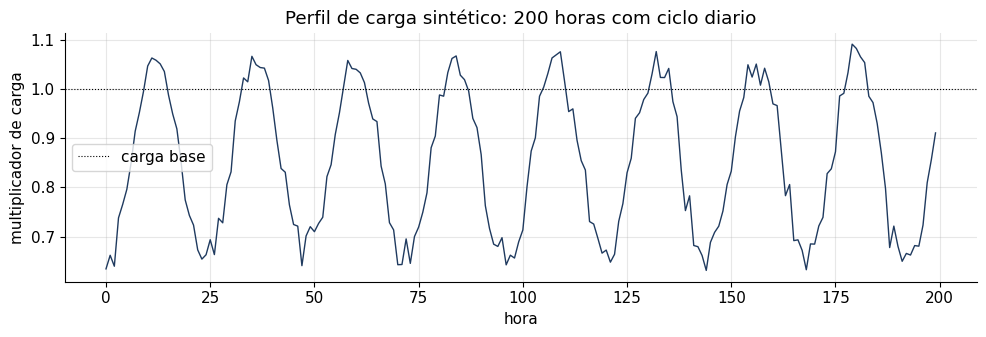

In [10]:
def perfil_de_carga(n_horas=200, pico=1.02, valle=0.65, seed=RANDOM_SEED):
    "Multiplicador horario da carga: senoide diária + ruído suave."
    g = np.random.default_rng(seed)
    t = np.arange(n_horas)
    diario = 0.5 * (pico + valle) + 0.5 * (pico - valle) * np.sin(2 * np.pi * (t - 6) / 24)
    return diario + g.normal(scale=0.02, size=n_horas)


mults = perfil_de_carga(200, pico=1.06)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(mults, color=AZUL, lw=1)
ax.axhline(1.0, color="k", ls=":", lw=0.8, label="carga base")
ax.set_xlabel("hora"); ax.set_ylabel("multiplicador de carga")
ax.set_title("Perfil de carga sintético: 200 horas com ciclo diario")
ax.legend(); plt.tight_layout(); plt.show()

### 3.2 O laço do painel, linha a linha

Para cada hora: escalar as cargas → resolver o OPF → guardar **três coisas à vez**:
os 30 LMPs, o número de restrições ativas, e o % de carga de cada linha (vamos usá-lo
em §3.4 para construir um regressor). Se uma hora não converge, fica como `NaN`.

In [11]:
def painel_dcopf(net, multiplicadores):
    "Resuelve um OPF por hora. Devuelve (painel LMP, n° binding por hora, loadings de linha)."
    cargas_base = net.load["p_mw"].values.copy()      # para restaurar ao final
    barras = sorted(net.bus.index)
    lmps, n_bind, loadings = [], [], []
    for m in multiplicadores:
        net.load["p_mw"] = cargas_base * m            # escalar TODA a demanda
        try:
            pp.rundcopp(net)
            lmps.append(net.res_bus["lam_p"].reindex(barras).values)
            n_bind.append(int((net.res_line.loading_percent > 99.9).sum())
                          + int((net.res_trafo.loading_percent > 99.9).sum()))
            loadings.append(net.res_line["loading_percent"].values)
        except Exception:                              # hora infactível
            lmps.append(np.full(len(barras), np.nan))
            n_bind.append(np.nan)
            loadings.append(np.full(len(net.line), np.nan))
    net.load["p_mw"] = cargas_base                     # dejar a rede como estaba
    painel = pd.DataFrame(lmps, columns=barras); painel.index.name = "hora"
    return painel, pd.Series(n_bind, name="binding"), np.array(loadings)


painel, binding, loadings = painel_dcopf(net, mults)
painel_ok = painel.dropna()
print(f"Painel: {painel.shape} | horas factíveis: {len(painel_ok)}/{len(painel)}")
print(f"Horas infactíveis (pico extremo => corte de carga): {painel.isna().any(axis=1).sum()}")
print(f"LMP medio: {painel_ok.values.mean():.2f} $/MWh | "
      f"desvio (hora, bus): {painel_ok.values.std():.2f}")
print("Distribução do n° de restrições ativas por hora:")
print(binding.value_counts().sort_index().to_string())

Painel: (200, 30) | horas factíveis: 182/200
Horas infactíveis (pico extremo => corte de carga): 18
LMP medio: 39.73 $/MWh | desvio (hora, bus): 7.10
Distribução do n° de restrições ativas por hora:
binding
1.0    145
2.0     18
3.0     19


### 3.3 O painel completo num relance: heatmap horas × barras

Uma figura que a análise por estatísticos resume mas não mostra: **todo o painel**. Dois
decisões de desenho para que a geografia seja *visível*:

1. Não graficamos o LMP cru (dominado pelo nível comum que sobe e baixa com a carga)
   mas sim o **desvio em relação à média horária**: $LMP_i(t) - \overline{LMP}(t)$. Vermelho =
   mais caro que a média dessa hora; azul = mais barato; branco = preço igual à
   média.
2. Ordenamos as linhas (barras) pelo seu desvio médio, para que os lados do penhasco de
   preços fiquem como blocos contíguos. As horas infactíveis aparecem em cinza.

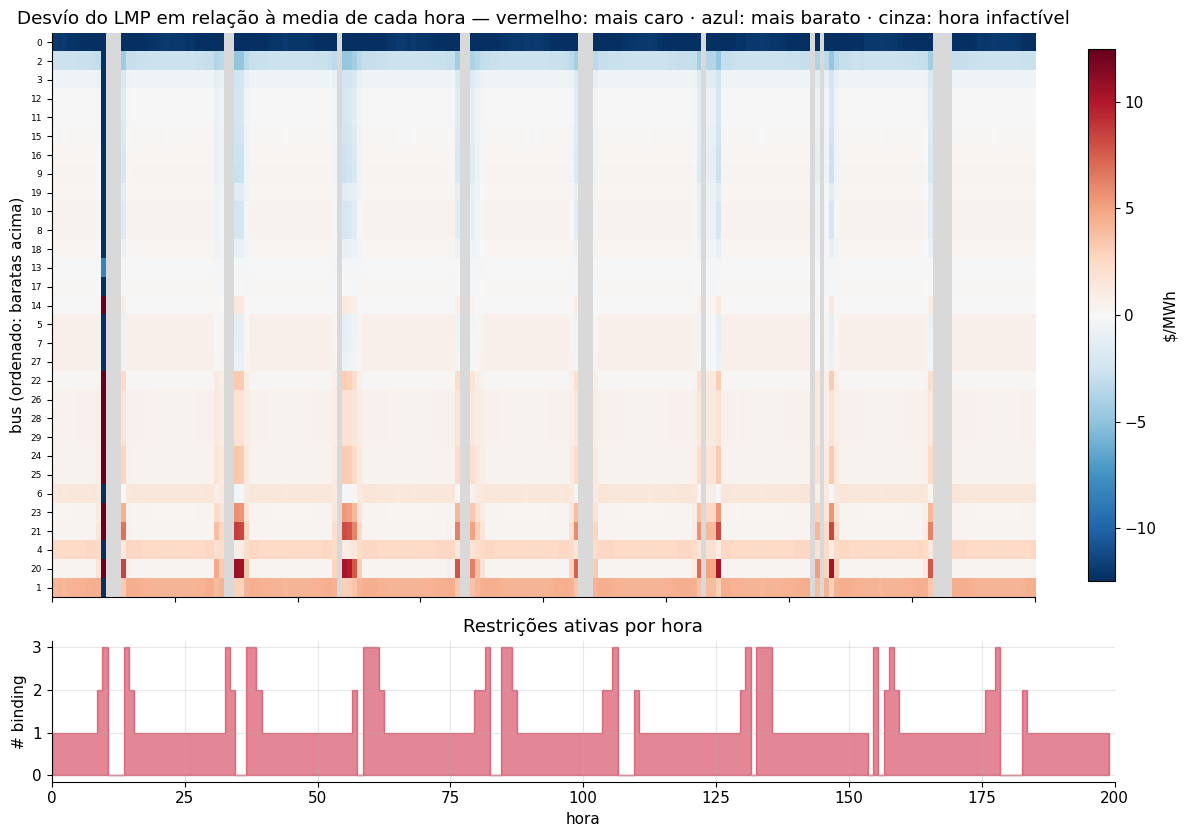

In [12]:
# Desvío em relação à MEDIA transversal de cada hora (sobre o painel completo,
# com NaN nas horas infactíveis para mantener o eje de tiempo alinhado).
desvio = painel.sub(painel.mean(axis=1), axis=0)
orden_barras = desvio.mean(axis=0).sort_values().index    # baratas acima, caras abaixo
M = desvio[orden_barras].T.values                          # 30 linhas x 200 horas
vmax = np.nanpercentile(np.abs(M), 98)                    # escala robusta

fig, axes = plt.subplots(2, 1, figsize=(12, 8.5), sharex=True,
                         gridspec_kw={"height_ratios": [4, 1]})
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#d9d9d9")                                   # horas infactibles en gris
im = axes[0].imshow(np.ma.masked_invalid(M), aspect="auto", cmap=cmap,
                    vmin=-vmax, vmax=vmax, extent=[0, len(painel), len(barras), 0])
axes[0].set_yticks(np.arange(len(barras)) + 0.5)
axes[0].set_yticklabels(orden_barras, fontsize=6.5)
axes[0].set_ylabel("bus (ordenado: baratas acima)"); axes[0].grid(False)
axes[0].set_title("Desvío do LMP em relação à media de cada hora — "
                  "vermelho: mais caro · azul: mais barato · cinza: hora infactível")
plt.colorbar(im, ax=axes[0], label="$/MWh", fraction=0.025)

axes[1].fill_between(range(len(binding)), 0, binding.fillna(0).values,
                     color=VERMELHO, alpha=0.5, step="mid")
axes[1].set_xlabel("hora"); axes[1].set_ylabel("# binding")
axes[1].set_title("Restrições ativas por hora")
plt.tight_layout(); plt.show()

💡 **Interpretação.** Três estructuras convivem na figura:

- **A banda azul fina e persistente do topo** (barras 0–2): é a generação barata
  presa atrás da linha 0→1, que satura *quase todas as horas* (painel inferior:
  binding = 1 é o estado normal do sistema). O penhasco existe sempre, mas é
  estreito: separa duas ou três barras do resto, que fica quase branco (preço ≈ uniforme).
- **As colunas largas vermelho/azul** coincidem exatamente com as horas de 3 restrições
  ativas do painel inferior: quando saturam as linhas do anel de 33 kV, **a partição
  muda de escala** — já não são 3 barras contra 27, mas sim blocos inteiros separados por
  até ±\$12/MWh. Esta é a mudança de regime das horas de pico, e é o regime que
  estudaremos em §5.
- **As colunas cinzentas** são as horas infactíveis do pico extremo, alinhadas com os
  máximos de carga.

O resto da sessão analisa estatísticamente o que este heatmap já mostra a olho nu:
**o preço tem estrutura espacial, e essa estrutura muda de regime com a congestionamento.**



---
## 4 · Os preços se agrupam no espaço? O estatístico de Moran

### 4.1 O que mede Moran's $I$ (para quien o ve por primeira vez)

$$I \;=\; \frac{n}{\sum_{ij} w_{ij}}\cdot
\frac{\sum_{ij} w_{ij}\,(y_i - \bar y)(y_j - \bar y)}{\sum_i (y_i - \bar y)^2}$$

É a **correlação de cada barra com o médio de seus vizinhas** (definidas por $W$):

- $I > 0$: valores parecidos se agrupam (zonas caras junto a zonas caras);
- $I \approx E[I] = -\tfrac{1}{n-1} \approx 0$: sem padrão espacial;
- $I < 0$: padrão de tablero de ajedrez.

A inferencia é por **permutações**: barajamos os valores entre barras 199 vezes e vemos
se o $I$ observado é raro baixo "não há espaço".

### 4.2 Dois $W$ candidatas, em formato PySAL

Probamos dois das quatro $W$ da Sessão 1: a **adjacência binaria** $A$ e a **PTDF
com limiar** (a que sabe de electricidad). PySAL quiere seu próprio objeto `W` — o
convertidor é curto.

In [13]:
def a_pysal(W_arr, ids):
    "ndarray (n×n) -> objeto W de libpysal, padronizado por linhas."
    s = W_arr.sum(axis=1); s = np.where(s == 0, 1.0, s)
    Wn = W_arr / s[:, None]
    vizinhos = {ids[i]: [ids[j] for j in np.where(Wn[i] > 0)[0]] for i in range(len(ids))}
    pesos   = {ids[i]: [Wn[i, j] for j in np.where(Wn[i] > 0)[0]] for i in range(len(ids))}
    return PysalW(vizinhos, pesos, silence_warnings=True)


# --- W = A : adjacência binaria (S1 §7, construção 1) -----------------------
n = len(barras)
W_adj = np.zeros((n, n))
for i, j, _x, _t in ramos_da_rede(net):
    W_adj[bidx[i], bidx[j]] = W_adj[bidx[j], bidx[i]] = 1.0

# --- W = PTDF com limiar (S1 §7, construção 3) ------------------------------
W_ptdf = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            W_ptdf[i, j] = np.max(np.abs(PTDF[:, i] - PTDF[:, j]))
W_ptdf[W_ptdf < np.quantile(W_ptdf[W_ptdf > 0], 0.75)] = 0.0

Wp_adj, Wp_ptdf = a_pysal(W_adj, barras), a_pysal(W_ptdf, barras)
print(f"Densidades: W_adj {(W_adj>0).mean():.1%} | W_ptdf {(W_ptdf>0).mean():.1%}")

Densidades: W_adj 9.1% | W_ptdf 24.2%


### 4.3 Moran hora por hora: o espaço se acende com a congestionamento

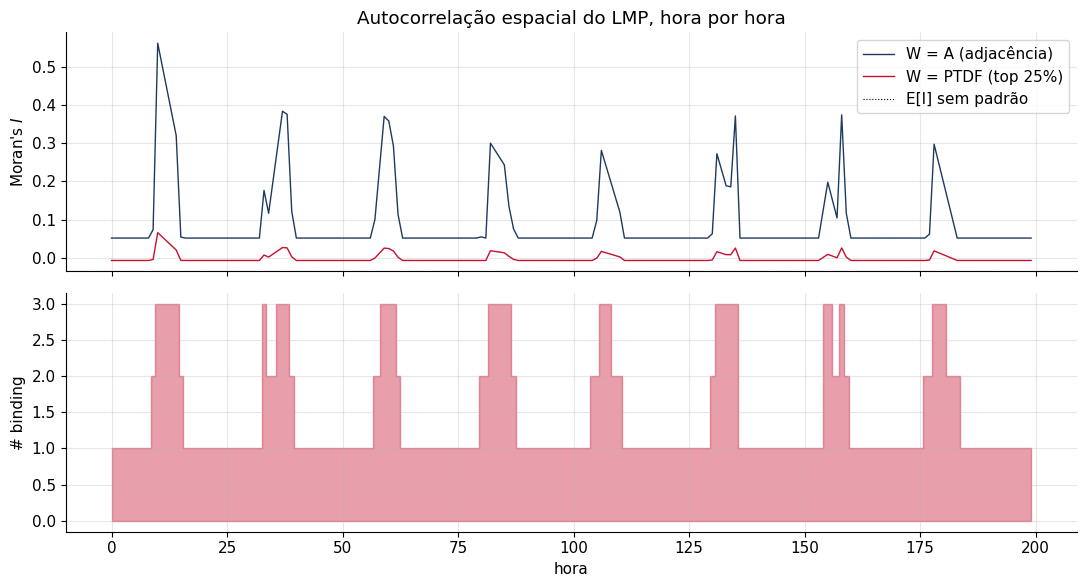

I medio  | W=A: +0.080   W=PTDF: -0.004
corr(|I_adj|, # binding) = +0.860


In [14]:
I_adj = painel_ok.apply(lambda fila: Moran(fila.values, Wp_adj, permutations=199,
                                          transformation="r").I, axis=1)
I_ptdf = painel_ok.apply(lambda fila: Moran(fila.values, Wp_ptdf, permutations=199,
                                           transformation="r").I, axis=1)
bind_ok = binding.reindex(painel_ok.index)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(I_adj.index, I_adj.values, c=AZUL, lw=1, label="W = A (adjacência)")
ax1.plot(I_ptdf.index, I_ptdf.values, c=VERMELHO, lw=1, label="W = PTDF (top 25%)")
ax1.axhline(-1 / (len(barras) - 1), color="k", ls=":", lw=0.8, label="E[I] sem padrão")
ax1.set_ylabel("Moran's $I$"); ax1.legend(loc="upper right")
ax1.set_title("Autocorrelação espacial do LMP, hora por hora")

ax2.fill_between(bind_ok.index, 0, bind_ok.values, color=VERMELHO, alpha=0.4, step="mid")
ax2.set_xlabel("hora"); ax2.set_ylabel("# binding")

plt.tight_layout(); plt.show()
print(f"I medio  | W=A: {I_adj.mean():+.3f}   W=PTDF: {I_ptdf.mean():+.3f}")
print(f"corr(|I_adj|, # binding) = {I_adj.abs().corr(bind_ok.astype(float)):+.3f}")

💡 **Interpretação.** Duas mensagens:

1. **A autocorrelação espacial do LMP é um fenômeno de congestionamento.** Nas horas de vale
   (sem linhas saturadas) $I$ cai para o seu valor esperado: o sistema é espacialmente
   "plano". Quando uma linha satura, $I_{adj}$ salta — o preço se parte em zonas. A
   correlação de $|I_{adj}|$ com o contagem de restrições ativas (≈ +0.86) o quantifica.
2. **Surpresa instructiva:** sob a $W$ PTDF, $I$ fica ≈ 0 todo o painel. "Falha" a $W$
   elétrica? Não — faz exatamente o que lhe pedimos. Essa $W$ conecta os pares de barras
   cuja transação mais move as linhas, e esses pares estão tipicamente em **lados opostos**
   do penhasco de preços. *Vizinho segundo $W_{PTDF}$* ≠ preço parecido: preço
   divergente! As duas $W$ codificam **hipótese distintas** sobre a interação — a
   lição central da Sessão 1, agora com consequências empíricas visíveis. Para "valores
   similares se agrupam", a adjacência é a $W$ correta; a PTDF servirá quando a
   hipótese seja de acoplamento físico (p. ex., no capstone).


---
## 5 · Da correlação ao modelo: OLS → diagnósticos → SAR/SEM

### 5.1 A pergunta de regressão

§4 nos deixou uma lição empírica: **a estrutura espacial do LMP só existe nas horas
congestionadas**. Então definimos a variável a explicar nesse regime:
$y_i$ = LMP médio da barra $i$ **sobre as horas com ≥ 2 restrições ativas**.
(Tirar a média de também as horas planas diluiria o sinal com ruído sem geografia — testem
como exercício.)

Os regressores, três características da barra:

| Regressor | O que mede | Sinal esperado |
|---|---|---|
| `betweenness` | centralidade topológica (S1) | + (os gargalos encarecem?) |
| `demanda` | MW de carga base na barra | + (bolsão de carga) |
| `exposicion` | frequência com que a barra toca uma linha saturada | **±** — cuidado! |

O sinal de `exposicion` é deliberadamente ambíguo: uma linha saturada tem **dois lados**
— o lado importador (caro) e o gerador preso (barato) — e ambos "tocam" a linha.
Veremos o que os dados decidem. O regressor se constrói do próprio painel: por cada linha, a
fração de horas em que saturó, repartida a seus duas barras extremas.

In [15]:
# --- os três regressores -------------------------------------------------------
btw = pd.Series(nx.betweenness_centrality(G30, normalized=True)).reindex(barras)
demanda = net.load.groupby("bus")["p_mw"].sum().reindex(barras, fill_value=0.0)

frec_sat = (loadings > 99.9).mean(axis=0)             # por linha: frac. de horas saturada
exposicao = pd.Series(0.0, index=barras)
for li, f in enumerate(frec_sat):
    if f > 0:
        exposicao[int(net.line.loc[li, "from_bus"])] += f
        exposicao[int(net.line.loc[li, "to_bus"])] += f

horas_cong = binding.reindex(painel_ok.index) >= 2      # o regime congestionado (§4)
print(f"Horas no regime congestionado: {int(horas_cong.sum())} de {len(painel_ok)}")
y = painel_ok[horas_cong].mean(axis=0).reindex(barras).values   # LMP medio em congestionamento
X = np.column_stack([btw.values, demanda.values, exposicao.values])
nombres_X = ["betweenness", "demanda", "exposicao"]

pd.DataFrame(X, index=barras, columns=nombres_X).describe().round(3)

Horas no regime congestionado: 37 de 182


,betweenness,demanda,exposicao
count,30.000,30.000,30.000
mean,0.082,9.447,0.061
std,0.105,17.750,0.231
min,0.000,0.000,0.000
25%,0.001,0.000,0.000
50%,0.034,3.500,0.000
75%,0.130,9.375,0.000
max,0.435,94.200,0.910


### 5.2 Manual de uso: ajustar regressões espaciais com `spreg`

Antes de rodar nada, o contrato da biblioteca. Todos os estimadores de `spreg`
compartilham a mesma interface:

```python
modelo = spreg.ESTIMADOR(y, X, w=W, ...)
```

| Argumento | O que espera | Error típico se vocês errarem |
|---|---|---|
| `y` | array **coluna** de forma `(n, 1)` → usar `y.reshape(-1, 1)` | `(n,)` plano rompe o estimador |
| `X` | matriz `(n, k)` **sem** coluna de uns (spreg adiciona a constante) | duplicar a constante |
| `w` | objeto `W` de `libpysal`, **padronizado por linhas** (nosso `a_pysal`) | passar o ndarray cru |
| `name_y`, `name_x`, `name_w` | etiquetas para que o `summary` seja legible | saídas com `var_1, var_2…` |

Os três estimadores que usamos hoje:

| Estimador | Modelo | Atributos-chave do objeto ajustado |
|---|---|---|
| `spreg.OLS(y, X, w=W, spat_diag=True, moran=True)` | $y = X\beta + \varepsilon$ + **diagnósticos espaciais** | `.betas`, `.t_stat`, `.summary` |
| `spreg.ML_Lag(y, X, w=W, method="full")` | SAR: $y = \rho Wy + X\beta + \varepsilon$ | `.rho`, `.betas`, `.z_stat`, `.logll`, `.aic`, `.pr2` |
| `spreg.ML_Error(y, X, w=W, method="full")` | SEM: $y = X\beta + u,\; u = \lambda Wu + \varepsilon$ | `.lam`, `.betas`, `.z_stat`, `.logll`, `.aic` |

Convenções que ahorran sustos: em `ML_Lag`, o vetor `.betas` traz
$[\beta_0, \beta_1, \ldots, \beta_k, \rho]$ — **a constante primeiro e $\rho$ ao final** — e
`.z_stat` é uma lista de pares $(z, p)$ no mesmo orden. `method="full"` calcula o
jacobiano $|I-\rho W|$ exacto (bem para $n$ de centenas; para miles, `method="ord"`).

### 5.3 O passo obligatorio: os diagnósticos LM sobre o OLS

Por quê ajustar um OLS se sabemos que está mal? Porque a bateria de diagnósticos de
Anselin, Bera, Florax & Yoon (1996) **se calcula sobre os resíduos do OLS** — é o
procedimiento estándar para escolher entre SAR e SEM *antes* de estimarlos:

| Test | Pergunta | Se rejeita... |
|---|---|---|
| Moran's $I$ (resíduos) | ficou estrutura espacial sem explicar? | faz falta *algum* modelo espacial |
| LM-lag / LM-lag robusto | falta o termo $\rho W y$? | → **SAR** |
| LM-error / LM-error robusto | o error é espacial ($\lambda W u$)? | → **SEM** |

Regla de decisão: se ambos LM simples rejeitam, dirimen as versões **robustas** (cada uma
inmunizada contra a presencia do outro efeito). Imprimimos *só* o bloco de diagnósticos.

In [16]:
ols = spreg.OLS(y.reshape(-1, 1), X, w=Wp_adj, spat_diag=True, moran=True,
                name_y="LMP_cong", name_x=nombres_X, name_w="W_adj")

# Só nos interesa o bloco de diagnósticos espaciais do summary:
s = ols.summary
ini = s.find("DIAGNOSTICS FOR SPATIAL DEPENDENCE")
fin = s.find("- Spatial Durbin -")          # cortamos antes do bloco SDM (o citamos em §5.6)
print(s[ini:fin if fin > 0 else None])

DIAGNOSTICS FOR SPATIAL DEPENDENCE
- SARERR -
TEST                           MI/DF       VALUE           PROB
Moran's I (error)              0.2964        2.215           0.0268
Lagrange Multiplier (lag)         1          5.155           0.0232
Robust LM (lag)                   1          5.449           0.0196
Lagrange Multiplier (error)       1          3.254           0.0713
Robust LM (error)                 1          3.548           0.0596
Lagrange Multiplier (SARMA)       2          8.703           0.0129




💡 **Leitura dos diagnósticos, linha por linha:**

- **`Moran's I (error)`** ≈ 0.30 com p ≈ 0.027: os resíduos do OLS *estão* espacialmente
  autocorrelacionados ⇒ falta algo espacial no modelo. (Este test detecta o problema
  mas não diz qual é.)
- **`Lagrange Multiplier (lag)`**: p ≈ 0.023 — rejeita. **`Lagrange Multiplier (error)`**:
  p ≈ 0.071 — não rejeita ao 5%. Primeira pista: o problema parece ser o *lag*.
- **`Robust LM (lag)`**: p ≈ 0.020 — segue rechazando aun depois de inmunizarse contra o
  efeito error. **`Robust LM (error)`**: p ≈ 0.060 — não rejeita. A regra de Anselin é
  inequívoca: **o modelo indicado é o SAR**.

Estimem-no na célula seguinte — e o SEM como controle, para verificar que a escolha
importa pouco nas conclusões qualitativas, mas sim na interpretação.

### 5.4 Ajustar o SAR e ler seu saída completa

In [17]:
sar = spreg.ML_Lag(y.reshape(-1, 1), X, w=Wp_adj, method="full",
                   name_y="LMP_cong", name_x=nombres_X, name_w="W_adj")
print(sar.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :       W_adj
Dependent Variable  :    LMP_cong                Number of Observations:          30
Mean dependent var  :     41.9186                Number of Variables   :           5
S.D. dependent var  :      4.5740                Degrees of Freedom    :          25
Pseudo R-squared    :      0.3984
Spatial Pseudo R-squared:  0.2328
Log likelihood      :    -81.9867
Sigma-square ML     :     12.5459                Akaike info criterion :     173.973
S.E of regression   :      3.5420                Schwarz criterion     :     180.979

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------

In [18]:
# --- acceso programático aos resultados (para automatizar informes) ----------
print(f"rho        : {float(sar.rho):+.4f}")
print(f"z e p de rho: z = {float(sar.z_stat[-1][0]):+.2f}, p = {float(sar.z_stat[-1][1]):.4f}")
print(f"betas      : {np.ravel(sar.betas).round(3)}   # [const, ...X..., rho]")
print(f"log-lik    : {float(sar.logll):.2f} | AIC: {float(sar.aic):.2f} | "
      f"pseudo-R2: {float(sar.pr2):.3f}")

# O SEM como control (o LM-error robusto não o pedía, mas verificamos):
sem = spreg.ML_Error(y.reshape(-1, 1), X, w=Wp_adj, method="full",
                     name_y="LMP_cong", name_x=nombres_X, name_w="W_adj")
print(f"\nSEM de control: lambda = {float(sem.lam):+.3f} | AIC = {float(sem.aic):.2f} "
      f"(vs SAR {float(sar.aic):.2f})")

rho        : +0.4989
z e p de rho: z = +3.22, p = 0.0013
betas      : [21.287 -1.666  0.026 -5.797  0.499]   # [const, ...X..., rho]
log-lik    : -81.99 | AIC: 173.97 | pseudo-R2: 0.398
ML_Error

SEM de control: lambda = +0.475 | AIC = 173.81 (vs SAR 173.97)


💡 **Anatomia da saída do `ML_Lag`, bloco por bloco** (guardem este guia):

**Cabeçalho.** `Number of Observations: 30` e `Number of Variables: 5` — as 5 são constante
+ 3 regressores + $\rho$. Com $n=30$ e 5 parâmetros estamos no limite do razoável: os
intervalos serão largos, e está bem que se note.

**`Pseudo R-squared` e `Spatial Pseudo R-squared`.** Não são o $R^2$ de OLS (em ML não existe);
são correlações ao quadrado entre $y$ e as predições. O primeiro usa $\hat y$ com o
termo espacial incluído; o segundo, só $X\hat\beta$. A diferença entre ambos ≈ quanto
explica a rede por si só.

**A tabela de coeficientes.** Cada linha traz `Coefficient | Std.Error | z-Statistic | Prob.`
A inferência é assintótica (normal), por isso $z$ e não $t$. Regra rápida: $|z|>1.96$ ⇒
significativo ao 5%. Na nossa tabela:

- **`W_LMP_cong` (ou seja, $\hat\rho \approx +0.50$, z ≈ +3.2, p < 0.01):** a linha mais
  importante. O LMP de uma barra em congestionamento arrasta ≈ a metade do LMP médio de seus
  vizinhas. É a confirmação formal do contagio espacial que o heatmap de §3.3 mostraba.
- **`exposicion` ≈ −5.8 e significativa:** cada 0.1 de frequência de exposição a linhas
  saturadas, o LMP próprio baixa ≈ \$0.58/MWh, *manteniendo fijo o vizinhança*. O sinal
  negativo resolve a ambigüedad de §5.1: neste sistema o lado pegado às linhas
  saturadas é o exportador barato.
- **`demanda` ≈ +0.03:** \$0.03/MWh por MW de carga local — positivo como se esperaba,
  chico porque o grosso da variação é zonal, não local.
- **`betweenness` não significativa:** a centralidade topológica *sozinha* não fija o preço —
  coerente com a lição da S1 (a topología não basta sem a física).

⚠️ **Mas cuidado:** em um SAR estes $\beta$ **não** são efeitos marginais — cada barra
retroalimenta a seus vizinhas e de vuelta. A conversão correta é a próxima seção, e é
a única forma legítima de responder "quanto muda o preço se...?".

**Pie de tabela.** `Log likelihood`, `AIC`, `Schwarz` atenden para comparar especificações —
contra o SEM de control: AIC quase empatados (≈ 174), e por isso a bateria LM robusta de
§5.3 era o árbitro correcto, não o AIC.

### 5.5 A pieza clave: efeitos diretos, indiretos e totais

⚠️ **Em um SAR, $\beta_r$ NO é o efeito marginal.** Como $y = (I - \rho W)^{-1}(X\beta + \varepsilon)$,
a matriz de efeitos do regressor $r$ é $S_r = (I - \rho W)^{-1}\beta_r$, e de ella salen
(LeSage & Pace, 2009):

- **ADE** (direto) = médio da diagonal de $S_r$: efeito de $x_{ri}$ sobre $y_i$
  *na mesma barra* (incluye a retroalimentação que pasa pelos vizinhos e vuelve);
- **AIE** (indireto) = o resto: efeito sobre **as demás** barras — o *spillover*;
- **ATE** (total) = ADE + AIE $= \beta_r/(1-\rho)$ com $W$ padronizada por linhas.

Unidades: \$/MWh por unidade do regressor.

,regressor,direto,indireto,total,%indireto
0,betweenness,-1.847,-1.477,-3.324,44.425
1,demanda,0.029,0.023,0.052,44.425
2,exposicao,-6.428,-5.139,-11.567,44.425


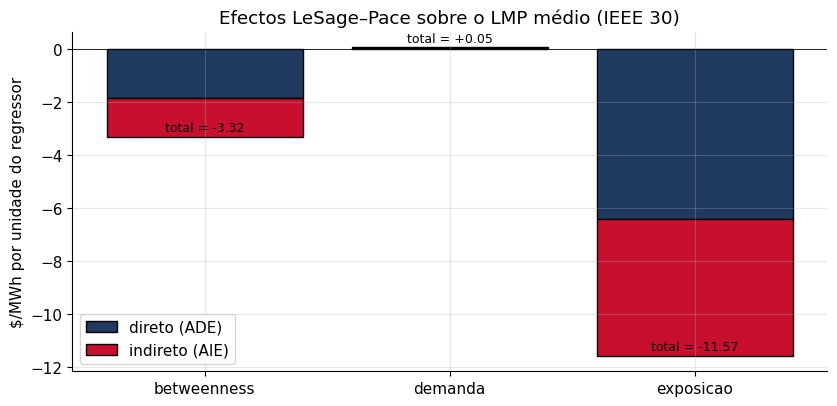

In [19]:
def padronizar_linhas(W):
    s = W.sum(axis=1); s = np.where(s == 0, 1.0, s)
    return W / s[:, None]


rho = float(sar.rho)
S = np.linalg.inv(np.eye(n) - rho * padronizar_linhas(W_adj))   # (I - ρW)⁻¹

efeitos = []
for k, nom in enumerate(nombres_X):
    beta_k = float(np.ravel(sar.betas)[1 + k])
    ade = np.mean(np.diag(S)) * beta_k            # diagonal: efeito próprio
    ate = S.sum(axis=1).mean() * beta_k           # linhas completas: efeito total
    efeitos.append({"regressor": nom, "direto": ade, "indireto": ate - ade,
                    "total": ate, "%indireto": 100 * (ate - ade) / ate if ate else np.nan})
efeitos = pd.DataFrame(efeitos).round(3)
display(efeitos)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(efeitos))
ax.bar(x, efeitos["direto"], color=AZUL, edgecolor="k", label="direto (ADE)")
ax.bar(x, efeitos["indireto"], bottom=efeitos["direto"], color=VERMELHO,
       edgecolor="k", label="indireto (AIE)")
for xi, (d, i) in enumerate(zip(efeitos["direto"], efeitos["indireto"])):
    ax.annotate(f"total = {d+i:+.2f}", (xi, d + i), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=9)
ax.axhline(0, color="k", lw=0.6)
ax.set_xticks(x); ax.set_xticklabels(efeitos["regressor"])
ax.set_ylabel("$/MWh por unidade do regressor")
ax.set_title("Efectos LeSage–Pace sobre o LMP médio (IEEE 30)")
ax.legend(); plt.tight_layout(); plt.show()

💡 **Interpretação (a frase para levar).** Quase a metade do efeito (≈ 44% indireto)
de qualquer intervenção **não ocorre onde se interviene**. Um planejador que leia só
$\beta$ (≈ efeito direto) subestimará sistematicamente o alcance da sua alavanca de política.
Esta tabela — não o summary do SAR — é o entregável para a tomada de decisões.

> 🔍 *Detalhe técnico:* em um SAR o *%indireto* é **idêntico para todos os regressores**
> (a matriz $S$ é compartilhada e só $\beta_r$ escala). Se vocês suspeitam que cada regressor
> transborda diferente, o modelo é o **SDM** (Durbin espacial, com termos $WX$) — vejam o
> test "LM for WX" do summary completo do OLS (`print(ols.summary)`).

### 5.6 *Onde* vive o sinal espacial? Moran scatterplot + mapa LISA

O $I$ global resume; o **LISA** (Moran local) localiza. Tomamos a hora com maior $|I|$ e
classificamos cada barra: **HH** (cara entre caras), **LL** (barata entre baratas), HL/LH
(outliers espaciais), NS (não significativa a 5%).

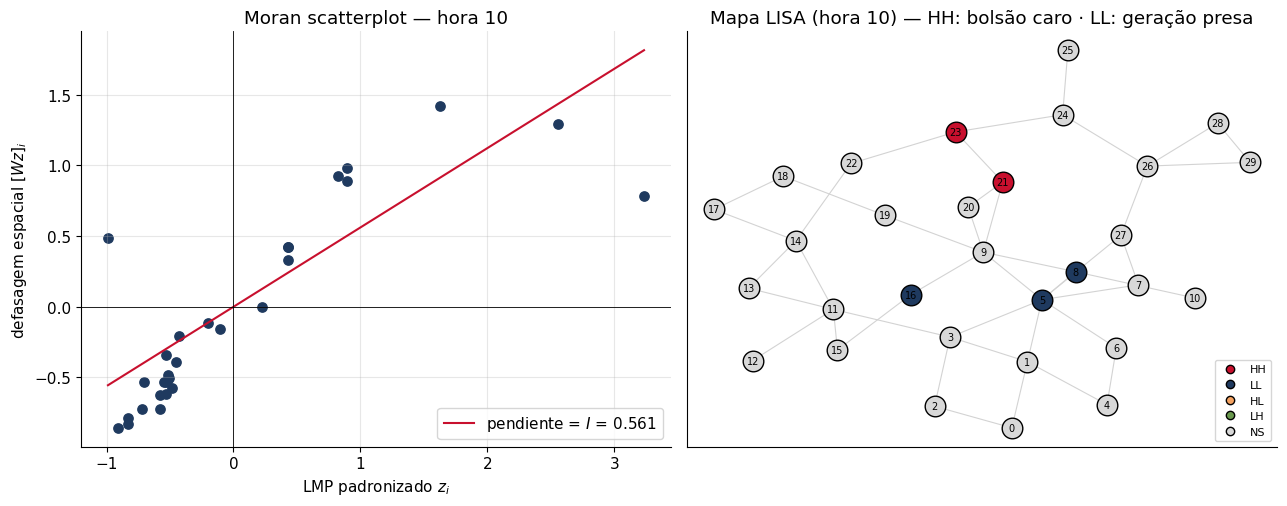

In [20]:
hora_foco = int(I_adj.abs().idxmax())
y_foco = painel_ok.loc[hora_foco].values

lisa = Moran_Local(y_foco, Wp_adj, permutations=999, transformation="r",
                   seed=RANDOM_SEED)
sig = lisa.p_sim < 0.05
etiquetas = np.array(["NS"] * n, dtype=object)
for q, lab in [(1, "HH"), (2, "LH"), (3, "LL"), (4, "HL")]:
    etiquetas[sig & (lisa.q == q)] = lab

z = (y_foco - y_foco.mean()) / y_foco.std(ddof=0)
Wz = padronizar_linhas(W_adj) @ z

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))
# --- (a) Moran scatterplot ---
ax1.scatter(z, Wz, c=AZUL, s=45)
pend = np.polyfit(z, Wz, 1)[0]
xs = np.linspace(z.min(), z.max(), 50)
ax1.plot(xs, pend * xs, color=VERMELHO, label=f"pendiente = $I$ = {pend:.3f}")
ax1.axhline(0, color="k", lw=0.6); ax1.axvline(0, color="k", lw=0.6)
ax1.set_xlabel("LMP padronizado $z_i$"); ax1.set_ylabel("defasagem espacial $[Wz]_i$")
ax1.set_title(f"Moran scatterplot — hora {hora_foco}"); ax1.legend()

# --- (b) mapa LISA ---
col = {"HH": VERMELHO, "LL": AZUL, "HL": "#f4a261", "LH": "#6a994e", "NS": "#d8d8d8"}
for u, v in G30.edges():
    (x1, y1), (x2, y2) = pos[u], pos[v]
    ax2.plot([x1, x2], [y1, y2], color="lightgray", lw=0.8, zorder=1)
for k, b in enumerate(barras):
    ax2.scatter(*pos[b], c=col[etiquetas[k]], s=220, edgecolors="k", zorder=3)
    ax2.annotate(str(b), pos[b], ha="center", va="center", fontsize=7, zorder=4)
leyenda = [plt.Line2D([0], [0], marker="o", ls="", mfc=c, mec="k", label=l)
           for l, c in col.items()]
ax2.legend(handles=leyenda, loc="lower right", fontsize=8)
ax2.set_title(f"Mapa LISA (hora {hora_foco}) — HH: bolsão caro · LL: geração presa")
ax2.set_xticks([]); ax2.set_yticks([]); ax2.grid(False)
plt.tight_layout(); plt.show()

💡 **Interpretação.** O cluster **HH** (vermelho) é o bolsão de carga congestionado; o **LL**
(azul) é a zona de geração presa atrás da linha saturada. Comparem com o mapa de
preços de §2.3: o LISA *redescubre estatísticamente* a fronteira física. E notem a
coerência metodológica: heatmap (§3.3) → Moran global (§4.3) → modelo (§5.3) → LISA — cada
ferramenta confirma e refina a anterior.

### ✏️ Exercício 2.1 — Robustez em $W$ `[intermediário · analisar]`

Re-estimen o SAR usando a $W$ de **distância elétrica** ($1/Z_{ef}$, S1 §7 construção 2)
e comparem $\hat\rho$. Sobrevive a conclusão (autocorrelação positiva e significativa) ao
mudança de $W$? *Autoverificação: ambos $\hat\rho \in (0, 1)$.*

In [21]:
# --- W de distância elétrica (S1 §7, construção 2) ---------------------------
B30 = laplaciano_suscetancias(net, bidx)
Bp = np.linalg.pinv(B30); dB = np.diag(Bp)
Z_ef = dB[:, None] + dB[None, :] - 2 * Bp; np.fill_diagonal(Z_ef, 0.0)
W_elec = np.where(Z_ef > 1e-9, 1.0 / np.where(Z_ef > 1e-9, Z_ef, 1.0), 0.0)

sar_elec = spreg.ML_Lag(y.reshape(-1, 1), X, w=a_pysal(W_elec, barras), method="full")
rho_elec = float(sar_elec.rho)

print(f"ρ com W_adj  = {rho:+.4f}")
print(f"ρ com W_elec = {rho_elec:+.4f}")
assert -1 < rho < 1 and -1 < rho_elec < 1
print(f"Cambia o sinal? {np.sign(rho) != np.sign(rho_elec)}")

ML_Lag
ρ com W_adj  = +0.4989
ρ com W_elec = +0.5310
Cambia o sinal? False


---
## 6 · Onde instalar generação? *Siting* no IEEE 118 (Lab 2b)

### 6.1 Um caso mais grande

Saltamos de 30 a **118 barras** (modelo reducido do Medio Oeste de EE.UU., anos 60): ~4×
as barras, ~6× as linhas, e uma distribuição de carga muito menos simétrica. Mais malha ⇒
mais caminhos para que o spillover se propague — o regime onde a decomposição
direto/indireto se torna decisiva.

In [22]:
def ieee118_para_opf():
    "IEEE 118 com limites realistas: 180 MVA em HV, 80 MVA no resto."
    net = pn.case118()
    for i, ln in net.line.iterrows():
        vn = net.bus.loc[int(ln.from_bus), "vn_kv"]
        net.line.loc[i, "max_i_ka"] = (180.0 if vn > 100 else 80.0) / (np.sqrt(3) * vn)
    net.line["max_loading_percent"] = 100.0
    net.trafo["max_loading_percent"] = 100.0
    return net


net118 = ieee118_para_opf()
mults118 = perfil_de_carga(48, pico=1.0, valle=0.75)
painel118, binding118, loadings118 = painel_dcopf(net118, mults118)
painel118_ok = painel118.dropna()
barras118 = sorted(net118.bus.index)
print(f"IEEE 118: {len(net118.bus)} barras, {len(net118.line)} linhas | "
      f"painel 48 h, factíveis: {len(painel118_ok)}/{len(painel118)}")
print(f"Spread médio do LMP: "
      f"{(painel118_ok.max(axis=1) - painel118_ok.min(axis=1)).mean():.2f} $/MWh")

IEEE 118: 118 barras, 173 linhas | painel 48 h, factíveis: 48/48
Spread médio do LMP: 12.87 $/MWh


### 6.2 O índice de aptidão para *DG siting*

Seguindo Faria et al. (2016): a aptidão de uma barra para alojar geração distribuída
combina quatro sinais, cada uma construída com peças que já dominamos:

| Componente | Construção | Por quê importa |
|---|---|---|
| `lmp_prom` | média do painel | preço ao qual o gerador venderia |
| `densidad_demanda` | carga total a ≤ 3 saltos no grafo | demanda que aliviaria |
| `exposicion_cong` | frec. de saturação das linhas incidentes | congestionamento que ajudaria a evitar |
| `potencial_renovável` | função suave das coordenadas (proxy solar) | recurso primário |

O índice é a soma ponderada dos componentes **padronizados** (pesos 0.35 / 0.20 /
0.20 / 0.25 — discutíveis, e por isso parametrizados).

In [23]:
def caracteristicas_siting(net, painel, loadings):
    "Matriz de regressores para a análise de siting (versão explicitada do helper)."
    barras = sorted(net.bus.index)
    G = grafo_topologico(net)

    # 1) preço médio
    lmp_prom = painel.dropna().mean(axis=0).reindex(barras).values

    # 2) demanda a <= 3 saltos
    carga = net.load.groupby("bus")["p_mw"].sum().reindex(barras, fill_value=0.0)
    dens = []
    for b in barras:
        bola = nx.single_source_shortest_path_length(G, b, cutoff=3)
        dens.append(float(carga.reindex(list(bola), fill_value=0.0).sum()))

    # 3) exposição a congestionamento: frequência de saturação de linhas incidentes
    frec = (loadings > 99.9).mean(axis=0)
    expo = pd.Series(0.0, index=barras)
    for li, f in enumerate(frec):
        if f > 0:
            expo[int(net.line.loc[li, "from_bus"])] += f
            expo[int(net.line.loc[li, "to_bus"])] += f

    # 4) potencial renovável: mais alto para o sur-oeste do layout (proxy solar)
    cps = coords_das_barras(net)
    xs = np.array([cps[b][0] for b in barras]); ys = np.array([cps[b][1] for b in barras])
    xn = (xs - xs.min()) / max(1e-6, float(np.ptp(xs))); yn = (ys - ys.min()) / max(1e-6, float(np.ptp(ys)))
    renov = 0.5 + 0.5 * (1 - xn) * (1 - yn)

    bt = nx.betweenness_centrality(G, normalized=True)
    return pd.DataFrame({
        "lmp_prom": lmp_prom,
        "betweenness": [bt[b] for b in barras],
        "densidade_demanda": dens,
        "exposicao_cong": expo.values,
        "potencial_renovável": renov,
    }, index=barras)


def indice_aptidao(feats, pesos=(0.35, 0.20, 0.20, 0.25)):
    "Suma ponderada dos componentes padronizados (z-scores)."
    z = (feats - feats.mean()) / feats.std(ddof=0).replace(0, 1.0)
    w_lmp, w_dem, w_cong, w_ren = pesos
    return (w_lmp * z["lmp_prom"] + w_dem * z["densidade_demanda"]
            + w_cong * z["exposicao_cong"]
            + w_ren * z["potencial_renovável"]).rename("aptidao")


feats118 = caracteristicas_siting(net118, painel118, loadings118)
aptidao = indice_aptidao(feats118)
print("Top-5 barras candidatas (índice de aptidão):")
display(aptidao.nlargest(5).round(3).to_frame())
feats118.describe().round(3)

Top-5 barras candidatas (índice de aptidão):


,aptidao
37,1.246
29,1.163
7,0.887
64,0.793
68,0.471


,lmp_prom,betweenness,densidade_demanda,exposicao_cong,potencial_renovável
count,118.000,118.000,118.000,118.000,118.000
mean,38.073,0.046,809.441,0.068,0.622
std,1.656,0.073,419.301,0.284,0.101
min,28.000,0.000,28.000,0.000,0.500
25%,37.277,0.001,526.500,0.000,0.541
50%,37.396,0.015,740.500,0.000,0.589
75%,39.423,0.058,1039.750,0.000,0.696
max,40.842,0.312,2225.000,2.000,0.846


### 6.3 SAR sobre o índice e a decisão que muda: ATE vs. ADE

Estimamos o SAR da aptidão sobre seus componentes e, com a matriz de efeitos
$S = (I-\rho W)^{-1}$, comparamos **dois rankings de investimento**:

- **ranking míope (ADE por barra):** ordena pelo efeito que a barra genera *sobre si mesma*;
- **ranking sistêmico (ATE por barra):** ordena pelo efeito total, *incluindo o que a
  barra propaga às suas vizinhas*.

In [24]:
nombres118 = ["betweenness", "densidade_demanda", "exposicao_cong", "potencial_renovável"]
X118 = feats118[nombres118].values
y118 = aptidao.reindex(barras118).values

W118 = np.zeros((len(barras118), len(barras118)))
bidx118 = {b: i for i, b in enumerate(barras118)}
for i, j, _x, _t in ramos_da_rede(net118):
    W118[bidx118[i], bidx118[j]] = W118[bidx118[j], bidx118[i]] = 1.0

sar118 = spreg.ML_Lag(y118.reshape(-1, 1), X118, w=a_pysal(W118, barras118),
                      method="full", name_y="aptidao", name_x=nombres118)
rho118 = float(sar118.rho)
print(f"ρ (IEEE 118) = {rho118:+.4f}   vs   ρ (IEEE 30) = {rho:+.4f}")
for nom, b, zz in zip(["const"] + nombres118, np.ravel(sar118.betas)[:-1],
                      [float(z[0]) for z in sar118.z_stat[:-1]]):
    print(f"  β_{nom:22s} = {float(b):+8.3f}  (z = {zz:+.2f})")

ML_Lag
ρ (IEEE 118) = +0.5817   vs   ρ (IEEE 30) = +0.4989
  β_const                  =   -0.577  (z = -3.34)
  β_betweenness            =   +0.923  (z = +2.23)
  β_densidade_demanda      =   +0.000  (z = +2.85)
  β_exposicao_cong         =   +0.150  (z = +1.69)
  β_potencial_renovável    =   +0.515  (z = +2.11)


In [25]:
S118 = np.linalg.inv(np.eye(len(barras118)) - rho118 * padronizar_linhas(W118))
betas118 = np.ravel(sar118.betas)[1:-1].reshape(-1, 1)   # pendientes

# Efecto por barra: quanto sobe a aptidão sistêmica se "mejoro" a barra b
ate_bus = (S118 @ X118 @ betas118).ravel()               # efeito total
ade_bus = (np.diag(S118)[:, None] * X118 @ betas118).ravel()   # só efeito próprio

ranking = pd.DataFrame({"bus": barras118, "ADE": ade_bus, "ATE": ate_bus,
                        "delta": ate_bus - ade_bus}).sort_values("ATE", ascending=False)
print("Top-10 candidatas por efeito TOTAL (a recomendação sistêmica):")
display(ranking.head(10).round(2))

top_ate = set(ranking.head(10).bus)
top_ade = set(ranking.sort_values("ADE", ascending=False).head(10).bus)
solo_ate = sorted(top_ate - top_ade)
print(f"Barras que SOLO aparecem no top-10 sistêmico (ATE): {solo_ate}")
print(f"=> o ranking míope se as perde.")

Top-10 candidatas por efeito TOTAL (a recomendação sistêmica):


,bus,ADE,ATE,delta
68,68,1.21,2.20,0.99
64,64,1.22,2.12,0.91
48,48,1.18,2.02,0.84
67,67,1.04,2.01,0.96
76,76,1.10,2.00,0.91
37,37,1.02,1.96,0.93
79,79,1.09,1.93,0.83
46,46,0.84,1.88,1.04
80,80,0.77,1.86,1.08
29,29,0.99,1.76,0.77


Barras que SOLO aparecem no top-10 sistêmico (ATE): [46, 80]
=> o ranking míope se as perde.


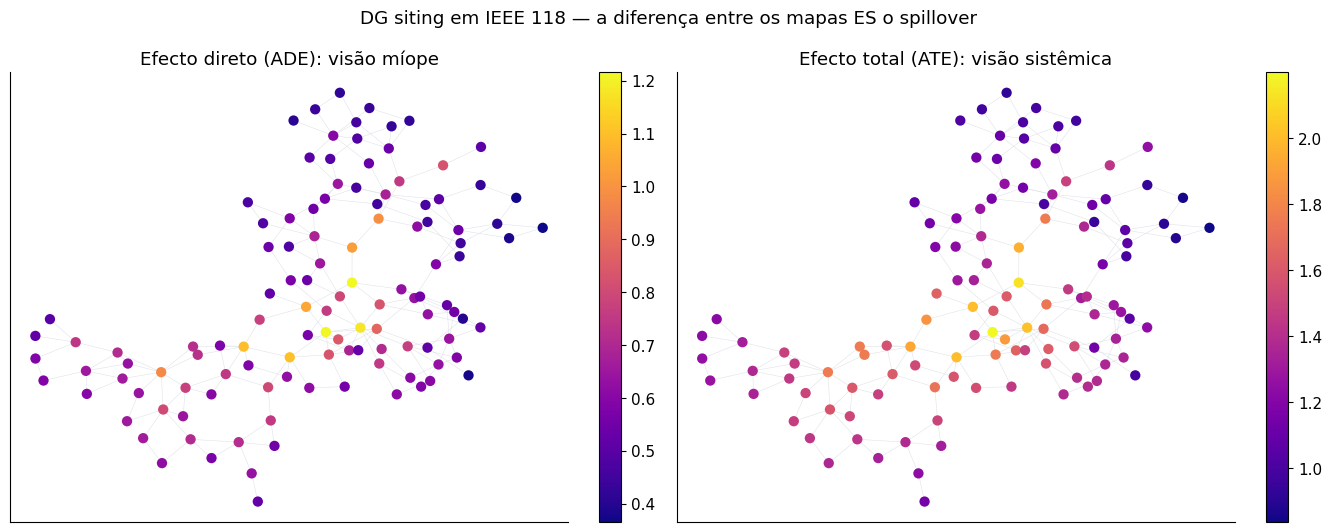

In [26]:
# --- Os dois mapas: efeito próprio vs. efeito total ------------------------------
pos118 = coords_das_barras(net118)
G118 = grafo_topologico(net118)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
for ax, (vec, titulo) in zip(axes, [(ade_bus, "Efecto direto (ADE): visão míope"),
                                     (ate_bus, "Efecto total (ATE): visão sistêmica")]):
    for u, v in G118.edges():
        (x1, y1), (x2, y2) = pos118[u], pos118[v]
        ax.plot([x1, x2], [y1, y2], color="#dfe3e8", lw=0.4, zorder=1)
    sc = ax.scatter([pos118[b][0] for b in barras118], [pos118[b][1] for b in barras118],
                    c=vec, cmap="plasma", s=55, edgecolors="none", zorder=2)
    plt.colorbar(sc, ax=ax, fraction=0.046)
    ax.set_title(titulo); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("DG siting em IEEE 118 — a diferença entre os mapas ES o spillover")
plt.tight_layout(); plt.show()

💡 **Interpretação.** O mapa da esquerda ilumina umas poucas
barras "estrela"; o da direita ilumina **regiões inteiras**, porque cada candidata
arrasta as suas vizinhas. As barras que só entram ao top-10 por ATE *não são os melhores
lugares para a barra onde se constrói — são os melhores lugares para o sistema*. Uma
regressão não-espacial é estruturalmente incapaz de ver essa diferença.

### ✏️ Exercício 2.2 — O deslocamento do ranking `[intermediário · analisar]`

Quantas barras do top-10 por ATE **não** estão no top-10 por ADE? Nomeiem 2–3 barras que
o ranking sistêmico promove, localizem-nas no mapa e proponham uma explicação topológica
(grau, posição em relação às linhas que saturam). *Autoverificação: os dois rankings não
podem ser idênticos.*



---
## 7 · Checagem de realidade: o benchmark RTS-GMLC (NREL)

Os IEEE são cômodos mas sintéticos. Fechamos com **RTS-GMLC**: 73 barras, mistura realista
de generação (carvão, gas, nuclear, hidro, **eólica e solar a custo marginal zero**) e
series horarias de carga de um ano inteiro. Predição antes de rodar: com renováveis
gratis presas tras linhas finitas, deveriam aparecer **LMPs negativos** — um fenômeno
documentado nas ISOs reais (Edmunds et al., 2018).

### 7.1 Obtener os dados (uma sozinha vez)

Os CSV vivem no repositorio público de NREL (licencia MIT). Esta célula os descarga se
não estão.

In [27]:
import urllib.request

DATA_DIR = Path("data/rts_gmlc"); DATA_DIR.mkdir(parents=True, exist_ok=True)
BASE = "https://raw.githubusercontent.com/GridMod/RTS-GMLC/master/RTS_Data"
ARCHIVOS = {
    "bus.csv":    f"{BASE}/SourceData/bus.csv",
    "branch.csv": f"{BASE}/SourceData/branch.csv",
    "gen.csv":    f"{BASE}/SourceData/gen.csv",
    "DAY_AHEAD_regional_Load.csv":
        f"{BASE}/timeseries_data_files/Load/DAY_AHEAD_regional_Load.csv",
}
for nombre, url in ARCHIVOS.items():
    destino = DATA_DIR / nombre
    if not destino.exists():
        print("descargando", nombre, "...")
        urllib.request.urlretrieve(url, destino)
RTS_OK = all((DATA_DIR / f).exists() for f in ARCHIVOS)
print("Datos RTS-GMLC disponívels:", RTS_OK)

Datos RTS-GMLC disponívels: True


### 7.2 Dos CSV a uma rede pandapower

O carregador traduz as três tabelas (`bus`, `branch`, `gen`) ao formato pandapower. As
decisões de modelagem estão comentadas no código — leiam-nas, porque *são* o modelo:
custo marginal térmico = `HeatRate × preço do combustível`; renováveis a custo 0;
limites de linha afrouxados ×1.3 para manter o OPF factível.

In [28]:
def carregar_rts_gmlc(data_dir=DATA_DIR, holgura_ratings=1.3):
    "Construye a rede RTS-GMLC para DC-OPF desde os CSV de NREL."
    bus_df = pd.read_csv(data_dir / "bus.csv")
    br_df = pd.read_csv(data_dir / "branch.csv")
    gen_df = pd.read_csv(data_dir / "gen.csv")
    net = pp.create_empty_network(sn_mva=100.0)

    # --- barras, com coordenadas reais (lng, lat) ---
    idx = {}
    for _, b in bus_df.iterrows():
        idx[int(b["Bus ID"])] = pp.create_bus(
            net, vn_kv=float(b["BaseKV"]), name=str(b["Bus Name"]),
            geodata=(float(b["lng"]), float(b["lat"])))

    # --- ramos: mesma tensão => linha; distinta => transformador ---
    bset = bus_df.set_index("Bus ID")
    for _, br in br_df.iterrows():
        f, t = int(br["From Bus"]), int(br["To Bus"])
        vf, vt = float(bset.loc[f, "BaseKV"]), float(bset.loc[t, "BaseKV"])
        mva = max(float(br.get("Cont Rating", 100.0)), 1.0)
        if abs(vf - vt) < 0.1:                          # linha: R, X em p.u. -> ohm
            pp.create_line_from_parameters(
                net, idx[f], idx[t], length_km=1.0,
                r_ohm_per_km=float(br["R"]) * vf**2 / 100.0,
                x_ohm_per_km=max(float(br["X"]), 1e-4) * vf**2 / 100.0,
                c_nf_per_km=0.0, max_i_ka=mva / (np.sqrt(3) * vf), name=str(br["UID"]))
        else:                                           # trafo: X p.u. -> vk%
            pp.create_transformer_from_parameters(
                net, hv_bus=idx[f if vf > vt else t], lv_bus=idx[t if vf > vt else f],
                sn_mva=mva, vn_hv_kv=max(vf, vt), vn_lv_kv=min(vf, vt),
                vk_percent=max(float(br["X"]), 0.001) * 100.0, vkr_percent=0.0,
                pfe_kw=0.0, i0_percent=0.0, name=str(br["UID"]))

    # --- cargas por barra ---
    for _, b in bus_df.iterrows():
        if float(b["MW Load"]) > 0:
            pp.create_load(net, idx[int(b["Bus ID"])], p_mw=float(b["MW Load"]),
                           controllable=False)

    # --- geradores: custo marginal = HeatRate x preço combustible ---
    #     (Solar/Wind/Hydro ficam em 0: ofertam gratis e o OPF os toma primeiro)
    slack_puesto = False
    for _, g in gen_df.iterrows():
        pmax = float(g["PMax MW"])
        if pmax <= 0: continue
        try:
            mc = max(float(g["HR_avg_0"]) * float(g["Fuel Price $/MMBTU"]) / 1000.0, 0.0)
        except (ValueError, TypeError):
            mc = 0.0
        b = idx[int(g["Bus ID"])]
        if not slack_puesto and mc > 0 and pmax >= 100:   # slack: térmica grande
            eg = pp.create_ext_grid(net, bus=b, vm_pu=1.0, min_p_mw=0.0, max_p_mw=pmax)
            pp.create_poly_cost(net, eg, "ext_grid", cp1_eur_per_mw=mc)
            slack_puesto = True
        else:
            gi = pp.create_gen(net, bus=b, p_mw=0.0, vm_pu=1.0, max_p_mw=pmax,
                               min_p_mw=0.0, controllable=True)
            pp.create_poly_cost(net, gi, "gen", cp1_eur_per_mw=mc)

    net.line["max_i_ka"] *= holgura_ratings
    net.line["max_loading_percent"] = 100.0
    net.trafo["max_loading_percent"] = 100.0
    return net


if RTS_OK:
    rts = carregar_rts_gmlc()
    print(f"RTS-GMLC: {len(rts.bus)} barras, {len(rts.line)} linhas, "
          f"{len(rts.trafo)} trafos, {len(rts.gen) + 1} geradores")
    print(f"Carga total: {rts.load.p_mw.sum():,.0f} MW "
          f"(≈ {rts.load.p_mw.sum() / net.load.p_mw.sum():.0f}× o IEEE 30)")

RTS-GMLC: 73 barras, 105 linhas, 15 trafos, 155 geradores
Carga total: 8,550 MW (≈ 30× o IEEE 30)


### 7.3 Uma semana real de preços — com a carga real de NREL

Desta vez os multiplicadores não são uma sinusoide inventada: são as **primeiras 168 horas**
da série de carga regional do próprio dataset.

Painel RTS: (168, 73) | factíveis 168/168
LMP medio 19.51 | min -3.38 <- sinal! | max 68.51
Preços NEGATIVOS: 280 pares (hora, bus) = 2.3%


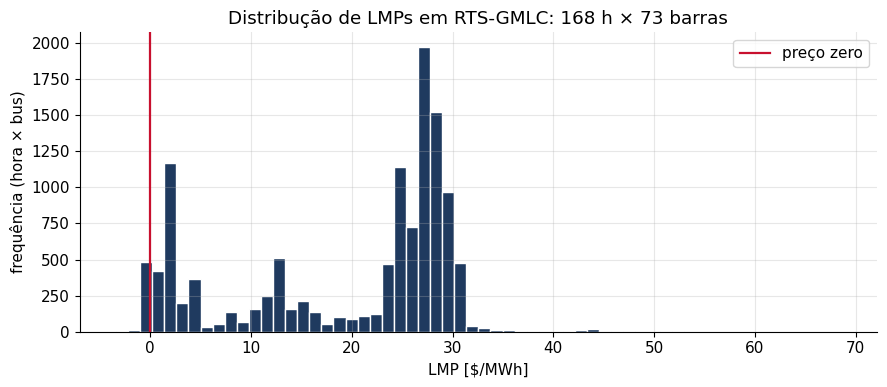

In [29]:
if RTS_OK:
    serie = pd.read_csv(DATA_DIR / "DAY_AHEAD_regional_Load.csv")["1"].iloc[:168].values
    mults_rts = serie / serie.mean()
    painel_rts, binding_rts, _ = painel_dcopf(rts, mults_rts)
    painel_rts_ok = painel_rts.dropna()
    todos_lmp = painel_rts_ok.values.ravel()

    print(f"Painel RTS: {painel_rts.shape} | factíveis {len(painel_rts_ok)}/{len(painel_rts)}")
    print(f"LMP medio {todos_lmp.mean():.2f} | min {todos_lmp.min():.2f} <- sinal! | "
          f"max {todos_lmp.max():.2f}")
    n_neg = int((todos_lmp < 0).sum())
    print(f"Preços NEGATIVOS: {n_neg} pares (hora, bus) = {100 * n_neg / todos_lmp.size:.1f}%")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(todos_lmp, bins=60, color=AZUL, edgecolor="white")
    ax.axvline(0, color=VERMELHO, lw=1.6, label="preço zero")
    ax.set_xlabel("LMP [$/MWh]"); ax.set_ylabel("frequência (hora × bus)")
    ax.set_title("Distribução de LMPs em RTS-GMLC: 168 h × 73 barras")
    ax.legend(); plt.tight_layout(); plt.show()

💡 **Há preços negativos!** Como pode um MWh valer *menos que zero*? A hipótese:
em certas horas, generação renovável **gratuita** fica presa atrás de linhas saturadas;
o excedente não pode ser exportado e o dual do balanço se torna negativo. 

### 7.4 Autópsia de um preço negativo

**Evidência 1 — quando ocorrem?** Se a hipótese é correta, os negativos devem
concentrarse em horas de **carga baixa** (quando o excedente renovável é maior).

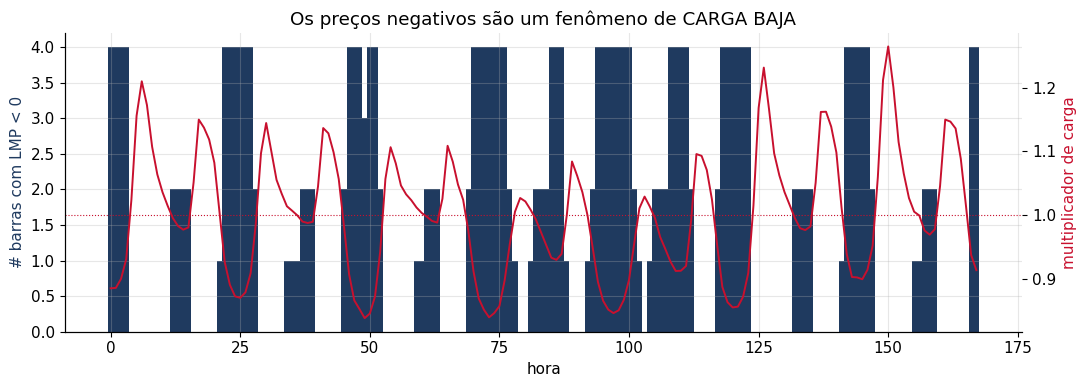

corr(# barras negativas, carga horaria) = -0.887
Horas com algum preço negativo: 98/168 | carga media em essas horas: 0.936 (vs 1.0 médio)


In [30]:
if RTS_OK:
    negs_por_hora = (painel_rts_ok < 0).sum(axis=1)

    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.bar(negs_por_hora.index, negs_por_hora.values, color=AZUL, width=1.0,
            label="# barras com LMP < 0")
    ax1.set_xlabel("hora"); ax1.set_ylabel("# barras com LMP < 0", color=AZUL)
    ax2 = ax1.twinx()
    ax2.plot(range(len(mults_rts)), mults_rts, color=VERMELHO, lw=1.4,
             label="multiplicador de carga")
    ax2.axhline(1.0, color=VERMELHO, ls=":", lw=0.8)
    ax2.set_ylabel("multiplicador de carga", color=VERMELHO); ax2.grid(False)
    ax1.set_title("Os preços negativos são um fenômeno de CARGA BAJA")
    plt.tight_layout(); plt.show()

    corr_neg = np.corrcoef(negs_por_hora.values,
                           mults_rts[:len(negs_por_hora)])[0, 1]
    print(f"corr(# barras negativas, carga horaria) = {corr_neg:+.3f}")
    print(f"Horas com algum preço negativo: {(negs_por_hora > 0).sum()}/168 | "
          f"carga media em essas horas: {mults_rts[negs_por_hora.values > 0].mean():.3f} "
          f"(vs 1.0 médio)")

💡 A correlação ≈ **−0.9** confirma a primeira metade da hipótese: os negativos vivem
nas horas de carga baixa, quando a renovável gratuita sobra. Falta a segunda metade: que
a causa seja renovável **presa** pela rede.

**Evidência 2 — dissecação da pior hora.** Tomamos a hora com o LMP mais negativo e fazemos a
autópsia: quais linhas saturam?, há renovável *recortada* (despachada abaixo
da sua capacidade apesar de custar \$0)?, onde fica a barra do preço negativo em relação a
todo isso? Um detalhe a antecipar: esta hora em particular **não** é de carga mínima
(multiplicador ≈ 1.01) — os negativos extremos precisam *as duas coisas ao mesmo tempo*: muita
renovável disponível **e** linhas saturadas que a prendam; a saturação requer fluxos
grandes. A evidência 1 (agregada) e esta (local) se complementam, não competem.

Hora 104: multiplicador de carga 1.013
LMP mínimo: -3.38 $/MWh no bus 16 (Aston)
Ramos saturadas: 3 linhas, 0 trafos
Renovable instalada 6,474 MW | despachada 6,253 MW => RECORTE = 221 MW
  - gen 150 (bus 64): recortado 221 MW a pesar de costar $0/MWh
Mientras tanto, térmica despachada: 2,411 MW


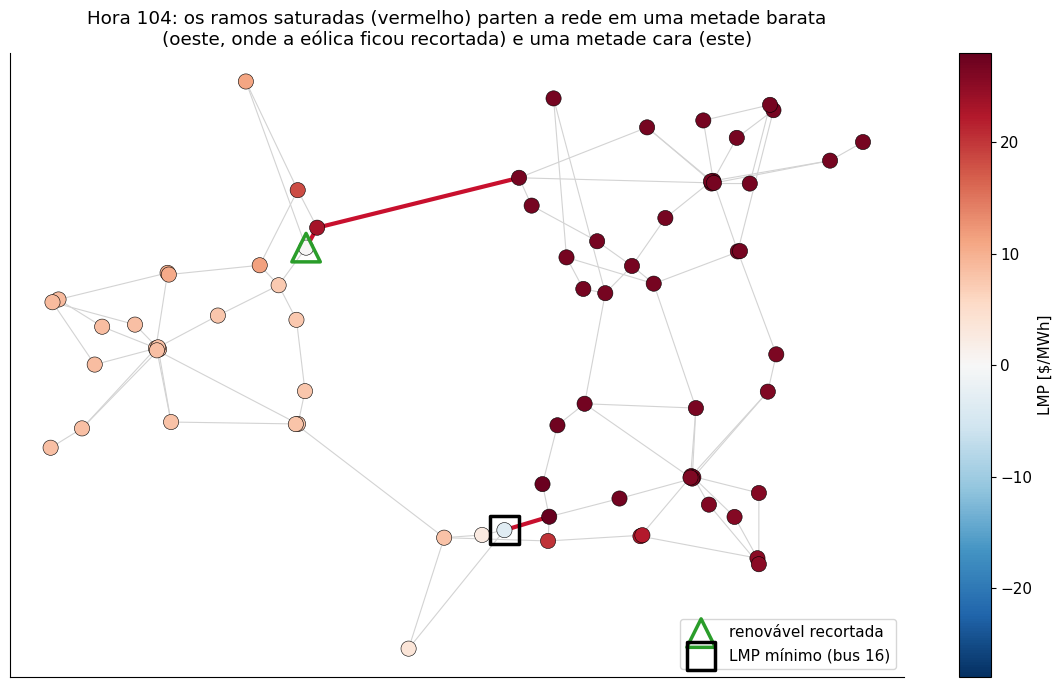

In [31]:
if RTS_OK:
    import copy

    h_neg = int(painel_rts_ok.min(axis=1).idxmin())          # a hora mais extrema
    b_neg = int(painel_rts_ok.loc[h_neg].idxmin())           # ...e seu barra

    rts_x = copy.deepcopy(rts)                              # copia de trabalho
    rts_x.load["p_mw"] = rts.load["p_mw"].values * mults_rts[h_neg]
    pp.rundcopp(rts_x)
    lam_h = rts_x.res_bus.lam_p

    # custos marginais por gerador (para identificar as renováveis: mc = 0)
    mc_gen = (rts_x.poly_cost.query("et == 'gen'")
              .set_index("element")["cp1_eur_per_mw"])
    gens_ren = mc_gen[mc_gen < 0.01].index
    cap_ren  = rts_x.gen.loc[gens_ren, "max_p_mw"]
    desp_ren = rts_x.res_gen.loc[gens_ren, "p_mw"]
    recorte  = (cap_ren - desp_ren)
    recortados = recorte[recorte > 1.0]

    print(f"Hora {h_neg}: multiplicador de carga {mults_rts[h_neg]:.3f}")
    print(f"LMP mínimo: {float(lam_h.min()):+.2f} $/MWh no bus {b_neg} "
          f"({rts_x.bus.loc[b_neg, 'name']})")
    print(f"Ramos saturadas: "
          f"{int((rts_x.res_line.loading_percent > 99.9).sum())} linhas, "
          f"{int((rts_x.res_trafo.loading_percent > 99.9).sum())} trafos")
    print(f"Renovable instalada {cap_ren.sum():,.0f} MW | despachada "
          f"{desp_ren.sum():,.0f} MW => RECORTE = {recorte.sum():,.0f} MW")
    for g, r in recortados.items():
        print(f"  - gen {g} (bus {int(rts_x.gen.loc[g, 'bus'])}): "
              f"recortado {r:,.0f} MW a pesar de costar $0/MWh")
    print(f"Mientras tanto, térmica despachada: "
          f"{rts_x.res_gen.loc[mc_gen[mc_gen >= 0.01].index, 'p_mw'].sum():,.0f} MW")

    # --- mapa da hora: LMP + ramos saturadas + renovável recortada ---
    pos_r = coords_das_barras(rts_x)
    G_r = grafo_topologico(rts_x)
    sat = set()
    for i, r in rts_x.line.iterrows():
        if rts_x.res_line.loading_percent[i] > 99.9:
            sat.add(frozenset((int(r.from_bus), int(r.to_bus))))
    for i, r in rts_x.trafo.iterrows():
        if rts_x.res_trafo.loading_percent[i] > 99.9:
            sat.add(frozenset((int(r.hv_bus), int(r.lv_bus))))

    fig, ax = plt.subplots(figsize=(11.5, 7))
    for u, v in G_r.edges():
        (x1, y1), (x2, y2) = pos_r[u], pos_r[v]
        if frozenset((u, v)) in sat:
            ax.plot([x1, x2], [y1, y2], color=VERMELHO, lw=3.0, zorder=2)
        else:
            ax.plot([x1, x2], [y1, y2], color="lightgray", lw=0.8, zorder=1)
    bb = sorted(rts_x.bus.index)
    sc = ax.scatter([pos_r[b][0] for b in bb], [pos_r[b][1] for b in bb],
                    c=lam_h.reindex(bb).values, cmap="RdBu_r", s=120,
                    vmin=-abs(lam_h).max(), vmax=abs(lam_h).max(),
                    edgecolors="k", linewidths=0.4, zorder=3)
    for g in recortados.index:                                 # eólica recortada
        bg = int(rts_x.gen.loc[g, "bus"])
        ax.scatter(*pos_r[bg], marker="^", s=420, facecolors="none",
                   edgecolors="#2a9d2a", linewidths=2.5, zorder=4,
                   label="renovável recortada")
    ax.scatter(*pos_r[b_neg], marker="s", s=420, facecolors="none",
               edgecolors="k", linewidths=2.5, zorder=4, label=f"LMP mínimo (bus {b_neg})")
    plt.colorbar(sc, label="LMP [$/MWh]")
    h_, l_ = ax.get_legend_handles_labels()
    porlab = dict(zip(l_, h_)); ax.legend(porlab.values(), porlab.keys(), loc="lower right")
    ax.set_title(f"Hora {h_neg}: os ramos saturadas (vermelho) parten a rede em uma metade "
                 "barata\n(oeste, onde a eólica ficou recortada) e uma metade cara (este)")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    plt.tight_layout(); plt.show()

💡 **O que mostra o mapa.** Os ramos saturadas (vermelho) partem a rede em duas metades de
preço: o oeste pálido/azulado (barato) e o leste vermelho escuro (caro). A eólica recortada
(triângulo verde) está **colada a uma das linhas saturadas**: seu corredor de evacuação
está cheio, e por isso 221 MW gratis ficam sem despachar enquanto o leste queima térmica
cara. O bus do preço negativo (quadrado preto) está junto a *outro* ramo saturado, do
lado barato. Notem que **não precisam estar juntos**: a PTDF da Sessão 1 é a que
conecta uma carga adicional no bus 16 com o alivio das linhas que engarrafam a
eólica. Isso é justamente o que o seguinte experimento verifica.

**Evidência 3 — o experimento definitivo: adicionar carga e ver o custo cair.** Se o LMP
do bus é −\$3.4/MWh, a teoria dual faz uma previsão falseável: **servir um MW adicional
de demanda nesse bus deveria REDUZIR o custo total do sistema** em ≈ \$3.4/h — porque essa
carga extra gera contrafluxo nos ramos cheios e "destrava" renovável recortada. O
probamos com incrementos crecientes e miramos as três colunas à vez: custo, preço e
recorte.

In [32]:
if RTS_OK:
    base = float(rts_x.res_cost)
    rec_base = float((cap_ren - desp_ren).sum())
    carga_exp = pp.create_load(rts_x, b_neg, p_mw=0.0, controllable=False)

    filas_exp = []
    for d in [0.5, 1, 2, 5, 10, 15, 20]:
        rts_x.load.loc[carga_exp, "p_mw"] = float(d)
        pp.rundcopp(rts_x)
        rec = float((rts_x.gen.loc[gens_ren, "max_p_mw"]
                     - rts_x.res_gen.loc[gens_ren, "p_mw"]).sum())
        filas_exp.append({
            "ΔMW": d,
            "ΔCusto [$/h]": float(rts_x.res_cost) - base,
            "ΔCusto/ΔMW": (float(rts_x.res_cost) - base) / d,
            "LMP no bus": float(rts_x.res_bus.lam_p[b_neg]),
            "recorte renov. [MW]": rec,
        })
    exp_df = pd.DataFrame(filas_exp).round(2)
    print(f"Custo base: {base:,.1f} $/h | recorte renovável base: {rec_base:.0f} MW")
    print()
    print(exp_df.to_string(index=False))

Custo base: 52,733.5 $/h | recorte renovável base: 221 MW

 ΔMW  ΔCusto [$/h]  ΔCusto/ΔMW  LMP no bus  recorte renov. [MW]
 0.5         -1.40       -2.80       -1.77               220.73
 1.0         -2.29       -2.29       -1.77               220.30
 2.0         -1.45       -0.73        1.06               219.42
 5.0          1.73        0.35        1.06               216.75
10.0          8.76        0.88        8.42               212.26
15.0         63.68        4.25       11.97               207.02
20.0        123.51        6.18       11.97               202.09


💡 **Interpretação: a hipótese fica demonstrada, com um bonus.**

1. **O dual se verifica empíricamente:** com +0.5 e +1 MW de carga no bus do preço
   negativo, o custo total do sistema **baixa** (≈ −\$2.3 a −2.8 por MW — da ordem do LMP
   marginal de −\$3.4). O sistema literalmente *agradece* que alguém consuma aí, porque
   cada MW consumido destapa renovável gratuita que estava cortada (vejam a coluna
   de corte cair) e desloca térmica cara em outro lugar.
2. **O bonus pedagógico:** sigam a coluna `LMP no bus` ao crescer a carga:
   −3.4 → −1.8 → +1.1 → +12. O preço negativo se **agota** exatamente quando o excedente
   preso se absorbe — e a trajetória não é linear. Lição: o LMP é um preço
   **marginal**, válido para perturbações pequenas; extrapolá-lo linearmente a decisões
   de 20 MW já dá o sinal errado. (Por isso os estudos de interconexão se fazem com
   re-despachos completos e não multiplicando LMPs.)
3. Isto não é um artefato do brinquedo: CAISO e ERCOT publican preços negativos em
   mediodías solares e madrugadas ventosas por exatamente este mecanismo (Edmunds et al.,
   2018). Nuestra cadena OPF + dados NREL o reproduce de punta a punta.

### 7.5 A estrutura espacial sobrevive na rede realista?

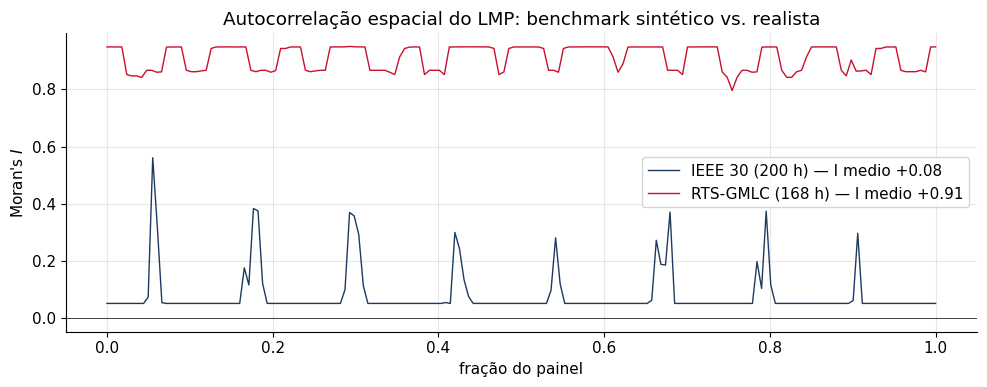

In [33]:
if RTS_OK:
    barras_rts = sorted(rts.bus.index)
    W_rts = np.zeros((len(barras_rts), len(barras_rts)))
    bidx_rts = {b: i for i, b in enumerate(barras_rts)}
    for i, j, _x, _t in ramos_da_rede(rts):
        W_rts[bidx_rts[i], bidx_rts[j]] = W_rts[bidx_rts[j], bidx_rts[i]] = 1.0
    Wp_rts = a_pysal(W_rts, barras_rts)

    I_rts = painel_rts_ok.apply(lambda f: Moran(f.values, Wp_rts, permutations=99,
                                               transformation="r").I, axis=1)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(np.linspace(0, 1, len(I_adj)), I_adj.values, c=AZUL, lw=1,
            label=f"IEEE 30 (200 h) — I medio {I_adj.mean():+.2f}")
    ax.plot(np.linspace(0, 1, len(I_rts)), I_rts.values, c=VERMELHO, lw=1,
            label=f"RTS-GMLC (168 h) — I medio {I_rts.mean():+.2f}")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel("fração do painel"); ax.set_ylabel("Moran's $I$")
    ax.set_title("Autocorrelação espacial do LMP: benchmark sintético vs. realista")
    ax.legend(); plt.tight_layout(); plt.show()

💡 **Interpretação.** No RTS a autocorrelação é **persistentemente** mais alta e mais
variável: o perfil real de carga + renováveis va saturamdo linhas *distintas* ao longo da
semana, e cada regime de congestionamento imprime sua própria geografia de preços. A metodologia
do IEEE 30 se transfere sem mudanças — mas a *história* é mais rica no benchmark realista.

### ✏️ Exercício 2.3 — SAR em RTS-GMLC `[síntese · avaliar]`

Estimen um SAR do LMP médio do RTS sobre `betweenness` e `demanda` por barra. Reportem
$\hat\rho$ e escrevam 2–3 frases comparando o spillover com o do IEEE 30. Por quê
poderia ser mais forte (ou mais fraco) na rede grande? *Autoverificação: $\hat\rho \in (-1, 1)$.*

In [34]:
if RTS_OK:
    G_rts = grafo_topologico(rts)
    bt_rts = pd.Series(nx.betweenness_centrality(G_rts, normalized=True)
                       ).reindex(barras_rts).fillna(0)
    dem_rts = rts.load.groupby("bus")["p_mw"].sum().reindex(barras_rts, fill_value=0.0)
    X_rts = np.column_stack([bt_rts.values, dem_rts.values])
    y_rts = painel_rts_ok.mean(axis=0).reindex(barras_rts).values

    sar_rts = spreg.ML_Lag(y_rts.reshape(-1, 1), X_rts, w=Wp_rts, method="full",
                           name_y="LMP_prom", name_x=["betweenness", "demanda"])
    rho_rts = float(sar_rts.rho)
    print(f"ρ RTS-GMLC = {rho_rts:+.4f}   |   ρ IEEE 30 = {rho:+.4f}")
    assert -1 < rho_rts < 1

ML_Lag
ρ RTS-GMLC = +0.9672   |   ρ IEEE 30 = +0.4989


---
## 8 · Capstone: a tabela de robustez sistema × $W$

Lição final de método: **nunca reportem um único $\hat\rho$ de uma única $W$**. Um análise
defensável mostra a matriz completa: sistemas nas linhas, as quatro construções de
$W$ da Sessão 1 nas colunas. (Com a regressão mínima $y$ = LMP médio,
$X$ = betweenness, para isolar o efeito de $W$.)

In [35]:
def W_knn_geo(net, k=4):
    "k vizinhos geográficos mais cercanos, simetrizada (S1 §7, construção 4)."
    barras_ = sorted(net.bus.index)
    cps = coords_das_barras(net)
    XY = np.array([cps[b] for b in barras_])
    D = np.sqrt(((XY[:, None, :] - XY[None, :, :]) ** 2).sum(-1))
    W = np.zeros((len(barras_), len(barras_)))
    for i in range(len(barras_)):
        W[i, np.argsort(D[i])[1:k + 1]] = 1.0
    return np.maximum(W, W.T)


def W_ptdf_de(net, q=0.75):
    PT, _r, _b = ptdf_da_rede(net)
    nn = PT.shape[1]; W = np.zeros((nn, nn))
    for i in range(nn):
        for j in range(nn):
            if i != j:
                W[i, j] = np.max(np.abs(PT[:, i] - PT[:, j]))
    W[W < np.quantile(W[W > 0], q)] = 0.0
    return W


def W_elec_de(net):
    barras_ = sorted(net.bus.index)
    bidx_ = {b: i for i, b in enumerate(barras_)}
    Bm = laplaciano_suscetancias(net, bidx_)
    Bp_ = np.linalg.pinv(Bm); d_ = np.diag(Bp_)
    Z = d_[:, None] + d_[None, :] - 2 * Bp_; np.fill_diagonal(Z, 0.0)
    return np.where(Z > 1e-9, 1.0 / np.where(Z > 1e-9, Z, 1.0), 0.0)


def W_adj_de(net):
    barras_ = sorted(net.bus.index)
    bidx_ = {b: i for i, b in enumerate(barras_)}
    W = np.zeros((len(barras_), len(barras_)))
    for i, j, _x, _t in ramos_da_rede(net):
        W[bidx_[i], bidx_[j]] = W[bidx_[j], bidx_[i]] = 1.0
    return W


# Para IEEE 30 usamos o regime congestionado (a e de §5); para RTS, o médio simple.
sistemas = [("IEEE_30", net, painel_ok[horas_cong])]
if RTS_OK:
    sistemas.append(("RTS_GMLC", rts, painel_rts_ok))

filas = []
for tag, net_, pnl in sistemas:
    barras_ = sorted(net_.bus.index)
    y_ = pnl.mean(axis=0).reindex(barras_).values
    bt_ = pd.Series(nx.betweenness_centrality(grafo_topologico(net_), normalized=True)
                    ).reindex(barras_).fillna(0).values.reshape(-1, 1)
    for w_tag, Wfn in [("adjacência", W_adj_de), ("electrica", W_elec_de),
                       ("ptdf", W_ptdf_de), ("knn_geo", W_knn_geo)]:
        try:
            m = spreg.ML_Lag(y_.reshape(-1, 1), bt_, w=a_pysal(Wfn(net_), barras_),
                             method="full")
            filas.append({"sistema": tag, "W": w_tag, "rho": float(m.rho)})
        except Exception:
            filas.append({"sistema": tag, "W": w_tag, "rho": np.nan})

tabla_rho = pd.DataFrame(filas).pivot(index="sistema", columns="W", values="rho")
print("ρ̂ estimado por (sistema, W):")
display(tabla_rho.round(3))

ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag


ML_Lag
ML_Lag


ρ̂ estimado por (sistema, W):


W,adjacência,electrica,knn_geo,ptdf
sistema,,,,
IEEE_30,0.535,0.563,0.542,0.300
RTS_GMLC,0.967,0.968,0.935,0.819


💡 **Interpretação.** O sinal e a ordem de magnitude de $\hat\rho$ devem sobreviver ao
mudança de $W$ para que a conclusão seja crível; a magnitude exata **sempre** depende de
$W$ — e isso não é um defeito do método mas sim um lembrete de que $W$ é uma *hipótese*
sobre o mecanismo de interação, não um parâmetro estimado.

---
## 9 · Conclusões

### O que fica demostrado (com seus números)

1. **O preço nodal é a sombra da rede.** Sem congestionamento, um só preço
   ($\lambda_E$ = \$10 no brinquedo); com uma linha a 100%, o preço se parte e a
   diferença é exatamente o valor marginal da capacidade de transmissão. No IEEE 30,
   duas linhas saturadas bastan para abrir um spread de ≈ \$18/MWh entre barras do *mesmo*
   sistema.

2. **A estrutura espacial dos preços é um fenômeno de regime.** O heatmap da
   componente de congestionamento e a serie horaria de Moran contam a mesma história:
   em horas de vale o sistema é espacialmente plano ($I \approx E[I]$); quando as linhas
   saturam, $I$ salta e a correlação $|I|$–congestionamento chega a ≈ +0.86. **Consecuencia
   metodológica:** a variável dependiente de uma regressão espacial de LMPs deve definirse
   no regime congestionado — promediar horas planas diluye o sinal.

3. **O protocolo de modelagem tem um orden, e o orden importa.** OLS não se ajusta para
   interpretarlo mas sim para *diagnosticar*: a bateria LM sobre seus resíduos (Moran p≈0.03,
   LM-lag robusto p≈0.02, LM-error robusto p≈0.06) escolhe o SAR sem ambigüedad. O SAR da
   $\hat\rho \approx +0.50$ (z≈+3.2): a metade do preço de uma barra congestionada é
   contagio de seus vizinhas.

4. **Os $\beta$ de um modelo espacial não se leen — se convertem.** A decomposição de
   LeSage–Pace mostra que ≈ 44% de qualquer efeito ocorre *fora* da barra intervenida.
   No IEEE 118 essa conversão muda a decisão: o top-10 de sitios para generação por
   efeito total (ATE) incluye barras (46, 80) que o ranking míope por efeito próprio
   descarta. **O entregable de uma análise espacial é a tabela de efeitos, não a tabela de
   coeficientes.**

5. **Os preços negativos do benchmark realista não são um bug — e o demostramos.**
   Correlação de −0.9 com a carga horaria, 221 MW de eólica recortada na pior hora, e
   o experimento dual: adicionar 1 MW de carga no bus de LMP −\$3.4 **reduce** o custo
   total do sistema. A cadena DC-OPF + dados NREL reproduce de punta a punta um fenômeno
   documentado em CAISO/ERCOT.

6. **Ninguna conclusão espacial vale sem a tabela de robustez em $W$.** O sinal de
   $\hat\rho$ sobrevivió às quatro construções da Sessão 1 nos dois sistemas
   (capstone); as magnitudes não — e isso está bem, porque $W$ é uma hipótese de mecanismo,
   não um parâmetro estimado.

### O que este análise NO diz (limitações honestas)

- **DC sem perdas e custos lineares:** falta a componente de perdas do LMP real e os
  efeitos de blocos de oferta; o AC-OPF e as ofertas por tramos mudam magnitudes, não a
  lógica.
- **$n = 30$ é chico** para máxima verossimilhança: os intervalos são largos e um par de
  barras influyentes podem mover $\hat\rho$. O IEEE 118 e o RTS mitigan, não eliminan.
- **Tratamos o painel como um corte transversal** (médio sobre horas congestionadas). A
  econometria espacial *de painel* (efeitos fijos espaciais, SAR dinámico) é o seguinte
  passo natural e o que um journal pediría.
- **$W$ é exógena e fija**, mas acabamos de ver que a topología *efectiva* muda com o
  regime de congestionamento (linhas distintas saturam em horas distintas). Modelos com $W$
  variável no tiempo são fronteira de investigação — e uma buena pergunta de tesis.

### O puente ao laboratório

Com isto têm o fluxo completo: **física → OPF → painel → diagnóstico → modelo → efeitos →
decisão**. No laboratório o vão recorrer solos sobre redes que não han visto, com
preços de congestionamento que terão que defender ante um regulador escéptico — incluyendo que
pasa quando os agentes mentem sobre seus custos.

### 📚 Referências

- Schweppe, Caramanis, Tabors & Bohn (1988). *Spot Pricing of Electricity.* Kluwer.
- Hogan (1992). Contract networks for electric power transmission. *J. Reg. Econ.* 4(3).
- Litvinov (2010). Design and operation of LMP-based electricity markets. *IET GTD* 4(2).
- Anselin, Bera, Florax & Yoon (1996). Simple diagnostic tests for spatial dependence. *RSUE* 26(1).
- LeSage & Pace (2009). *Introduction to Spatial Econometrics.* CRC Press.
- Faria et al. (2016). Spatial analysis of non-technical losses. LaPSEE/UNESP.
- Pereira & Saraiva (2011). Generation expansion planning. *Energy* 36(8).
- Edmunds, Bukhsh, Gill & Galloway (2018). LMP variability at distribution level. arXiv:1804.04550.
- Barrows et al. (2020). The IEEE Reliability Test System: RTS-GMLC. *PSCC*.
- Thurner et al. (2018). pandapower. *IEEE T-PWRS* 33(6).